# Import & Helpers

In [27]:
import sys
from importlib import reload
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from importlib import reload

if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")
if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

import noninteracting
from noninteracting import KagomeNagaosa
import interaction
import frg_kernel
import channels
import frg_flow
import patching
from patching import build_exactM_patchset, PatchPoint, PatchSet, plot_patchset, exact_M6_points_1bz

## Plot Helper

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import channels
import instability
import frg_flow
import interaction
import frg_kernel

from channels import SZ0ChannelBuilder
from instability import InstabilityConfig, diagnose_kernel_collection
from frg_flow import BareSZ0VertexFromInteraction, FRGFlowSolverSZ0
from frg_kernel import FlowConfig


# ============================================================
# Basic formatting / plotting helpers
# ============================================================

CHANNELS_ORDER = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]


def fmt_q(q, nd=3):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{nd}f}, {q[1]:.{nd}f})"


def hermitian_part(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)


def sign_aware_channel_score(channel_name, M):
    """
    Same logic as current solver sign-aware score:
      pp -> largest positive eigenvalue of Hermitian part
      ph -> absolute value of most negative eigenvalue of Hermitian part
    """
    H = hermitian_part(M)
    evals, _ = np.linalg.eigh(H)
    eval_pos_max = float(np.max(evals)) if evals.size else 0.0
    eval_neg_min = float(np.min(evals)) if evals.size else 0.0

    if channel_name.startswith("pp"):
        physical_score = max(eval_pos_max, 0.0)
        chosen_eval = eval_pos_max
        chosen_sign = "positive"
    elif channel_name.startswith("ph"):
        physical_score = max(-eval_neg_min, 0.0)
        chosen_eval = eval_neg_min
        chosen_sign = "negative"
    else:
        raise ValueError(f"Unknown channel name: {channel_name}")

    return {
        "eval_pos_max": eval_pos_max,
        "eval_neg_min": eval_neg_min,
        "physical_score": float(physical_score),
        "chosen_eval": float(chosen_eval),
        "chosen_sign": chosen_sign,
        "herm_resid": float(np.max(np.abs(M - M.conjugate().T))),
    }


def build_builder_from_solver(solver, *, Landau_F=None):
    if Landau_F is None:
        Landau_F = getattr(solver, "diagnosis_landau_F", False)
    return channels.SZ0ChannelBuilder.from_solver(
        solver.current_vertex_accessor(),
        solver,
        Landau_F=Landau_F,
    )


def evaluate_signaware_selected_Qs(builder, diagnosis_Qs, *, landau_F=False):
    rows = []
    kernel_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)
        kernel_store[iq] = {"Q": Q.copy(), "kernels": kernel_dict}

        for ch_name, ker in kernel_dict.items():
            info = sign_aware_channel_score(ch_name, ker.matrix)
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                **info,
            })

    df = pd.DataFrame(rows)
    return df, kernel_store


def evaluate_instability_selected_Qs(
    builder,
    solver,
    diagnosis_Qs,
    *,
    temperature=None,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    rows = []
    result_store = {}

    if temperature is None:
        temperature = float(solver.state.T)

    cfg = InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # IMPORTANT: keep diagnosis consistent with current flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = FlowConfig(
        temperature=float(temperature),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)

        res_dict = diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": Q.copy(), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store


def leading_row_from_df(df, score_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(score_col, ascending=False).iloc[0]


def plot_channel_bars(df, *, value_col, title, ylabel):
    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(CHANNELS_ORDER):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0][value_col]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Flow Helper

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Helpers: dataframe shaping / printing / plotting
# ============================================================

def _is_q0_vec(q, tol=1e-10):
    q = np.asarray(q, dtype=float)
    return bool(np.allclose(q, 0.0, atol=tol, rtol=0.0))


def _scores_at_qindex(df, q_index, value_col, channels_order=CHANNELS_ORDER):
    sub = df[df["Q_index"] == int(q_index)]
    out = {}
    for ch in channels_order:
        ss = sub[sub["channel"] == ch]
        out[ch] = float(ss.iloc[0][value_col]) if len(ss) else np.nan
    return out


def _leading_row(df, value_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(value_col, ascending=False).iloc[0]


def _format_channel_scores(score_map, channels_order=CHANNELS_ORDER):
    parts = []
    for ch in channels_order:
        val = score_map.get(ch, np.nan)
        if np.isfinite(val):
            parts.append(f"{ch}={val:.3e}")
        else:
            parts.append(f"{ch}=nan")
    return ", ".join(parts)


def _append_step_rows(storage, df, *, step_index, T, family):
    for _, row in df.iterrows():
        storage.append({
            "family": family,  # "kernel" or "instability"
            "step_index": int(step_index),
            "T": float(T),
            "Q_index": int(row["Q_index"]),
            "Q": np.asarray(row["Q"], dtype=float),
            "Qx": float(row["Qx"]),
            "Qy": float(row["Qy"]),
            "channel": str(row["channel"]),
            "value": float(row["physical_score"] if family == "kernel" else row["score"]),
        })


def _collapse_q_groups(history_df, *, q0_tol=1e-10):
    """
    Collapse selected Qs into two groups:
      - Q0 : exact q=0
      - QM : max over all nonzero selected Q's
    """
    rows = []
    for (family, step_index, T, channel), sub in history_df.groupby(["family", "step_index", "T", "channel"]):
        sub = sub.copy()
        q0_mask = sub["Q"].apply(lambda x: _is_q0_vec(x, tol=q0_tol)).values

        # Q=0
        sub_q0 = sub[q0_mask]
        q0_val = np.nan
        if len(sub_q0):
            q0_val = float(np.max(sub_q0["value"].values))
        rows.append({
            "family": family,
            "step_index": int(step_index),
            "T": float(T),
            "channel": channel,
            "Q_group": "Q0",
            "value": q0_val,
        })

        # Q=M group = max over all nonzero chosen Qs
        sub_qm = sub[~q0_mask]
        qm_val = np.nan
        if len(sub_qm):
            qm_val = float(np.max(sub_qm["value"].values))
        rows.append({
            "family": family,
            "step_index": int(step_index),
            "T": float(T),
            "channel": channel,
            "Q_group": "QM",
            "value": qm_val,
        })

    out = pd.DataFrame(rows).sort_values(["family", "Q_group", "step_index", "channel"]).reset_index(drop=True)
    return out


def plot_flow_group_curves(
    grouped_df,
    *,
    last_n_steps=None,
    ylog=True,
    title_prefix="RG flow",
    ylim=1e-2
):
    """
    Produce exactly 4 plots:
      1. Q=0 kernel score vs T
      2. Q=M kernel score vs T
      3. Q=0 instability score vs T
      4. Q=M instability score vs T
    """
    df = grouped_df.copy()

    if last_n_steps is not None:
        keep_steps = sorted(df["step_index"].unique())[-int(last_n_steps):]
        df = df[df["step_index"].isin(keep_steps)].copy()

    panels = [
        ("kernel", "Q0", "sign-aware kernel score"),
        ("kernel", "QM", "sign-aware kernel score"),
        ("instability", "Q0", "physical instability score"),
        ("instability", "QM", "physical instability score"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for ax, (family, q_group, ylabel) in zip(axes, panels):
        sub = df[(df["family"] == family) & (df["Q_group"] == q_group)].copy()

        for ch in CHANNELS_ORDER:
            ss = sub[sub["channel"] == ch].sort_values("step_index")
            if len(ss) == 0:
                continue

            y = ss["value"].to_numpy(dtype=float)
            x = ss["T"].to_numpy(dtype=float)

            if ylog:
                y = np.where(y > 0, y, np.nan)
                ax.set_yscale("log")

            ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=ch)

        ax.set_title(f"{title_prefix}: {family} / {q_group}")
        ax.set_xlabel("Temperature")
        ax.set_ylabel(ylabel)
        ax.set_ylim(bottom=ylim)
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def print_flow_step_summary(
    *,
    step_index,
    T,
    rhs_norm,
    signaware_df,
    instab_df,
):
    lead_kernel = _leading_row(signaware_df, "physical_score")
    lead_instab = _leading_row(instab_df, "score")

    lead_qi_kernel = int(lead_kernel["Q_index"])
    lead_qi_instab = int(lead_instab["Q_index"])

    kernel_scores_at_leadQ = _scores_at_qindex(signaware_df, lead_qi_kernel, "physical_score")
    instab_scores_at_leadQ = _scores_at_qindex(instab_df, lead_qi_instab, "score")

    print(
        f"step={step_index:4d} | "
        f"T={T:.6f} | rhs_norm={rhs_norm:.3e} | "
        f"lead_kernel={lead_kernel['channel']} @ Q{lead_qi_kernel}:{fmt_q(lead_kernel['Q'])} "
        f"score={float(lead_kernel['physical_score']):.3e}"
    )
    print("kernel scores:", _format_channel_scores(kernel_scores_at_leadQ))
    print(
        f"    lead_instability={lead_instab['channel']} @ Q{lead_qi_instab}:{fmt_q(lead_instab['Q'])} "
        f"score={float(lead_instab['score']):.3e}"
    )
    print("instability:", _format_channel_scores(instab_scores_at_leadQ))


def run_flow_with_tracking(
    solver,
    diagnosis_Qs,
    *,
    print_every=1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    """
    Manual RG flow with per-step diagnostics:
      - sign-aware kernel score
      - physical instability score

    Returns
    -------
    history : list[FlowStepRecord]
    signaware_history_df : pd.DataFrame
    instability_history_df : pd.DataFrame
    grouped_plot_df : pd.DataFrame
    """
    temps = solver.temperature_path
    signaware_rows = []
    instab_rows = []

    # -------------------------------
    # step 0
    # -------------------------------
    rec0 = frg_flow.FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    builder0 = build_builder_from_solver(solver, Landau_F=False)

    sign_df0, _ = evaluate_signaware_selected_Qs(builder0, diagnosis_Qs, landau_F=False)
    instab_df0, _ = evaluate_instability_selected_Qs(
        builder0,
        solver,
        diagnosis_Qs,
        temperature=float(temps[0]),
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    _append_step_rows(signaware_rows, sign_df0, step_index=0, T=float(temps[0]), family="kernel")
    _append_step_rows(instab_rows, instab_df0, step_index=0, T=float(temps[0]), family="instability")

    print_flow_step_summary(
        step_index=0,
        T=float(temps[0]),
        rhs_norm=0.0,
        signaware_df=sign_df0,
        instab_df=instab_df0,
    )

    if rec0.instability:
        print("\n[flow stopped at step 0]")
        print("reason:", rec0.instability_reason)
        signaware_history_df = pd.DataFrame(signaware_rows)
        instability_history_df = pd.DataFrame(instab_rows)
        grouped_plot_df = _collapse_q_groups(pd.concat([signaware_history_df, instability_history_df], ignore_index=True))
        return solver.history, signaware_history_df, instability_history_df, grouped_plot_df

    # -------------------------------
    # main loop
    # -------------------------------
    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])

        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        builder = build_builder_from_solver(solver, Landau_F=False)

        sign_df, _ = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=False)
        instab_df, _ = evaluate_instability_selected_Qs(
            builder,
            solver,
            diagnosis_Qs,
            temperature=rec.temperature,
            landau_F=False,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )

        _append_step_rows(signaware_rows, sign_df, step_index=rec.step_index, T=rec.temperature, family="kernel")
        _append_step_rows(instab_rows, instab_df, step_index=rec.step_index, T=rec.temperature, family="instability")

        if (rec.step_index % int(print_every) == 0) or rec.instability or rec.terminated_early:
            print_flow_step_summary(
                step_index=rec.step_index,
                T=rec.temperature,
                rhs_norm=rec.rhs_norm,
                signaware_df=sign_df,
                instab_df=instab_df,
            )

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            if rec.instability_reason is not None:
                print("instability_reason:", rec.instability_reason)
            if rec.termination_reason is not None:
                print("termination_reason:", rec.termination_reason)
            break

    signaware_history_df = pd.DataFrame(signaware_rows)
    instability_history_df = pd.DataFrame(instab_rows)
    grouped_plot_df = _collapse_q_groups(
        pd.concat([signaware_history_df, instability_history_df], ignore_index=True)
    )

    return solver.history, signaware_history_df, instability_history_df, grouped_plot_df

def run_flow_with_tracking_and_snapshots(
    solver,
    diagnosis_Qs,
    *,
    print_every=1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    temps = solver.temperature_path
    signaware_rows = []
    instab_rows = []
    snapshots = {}

    # step 0
    rec0 = frg_flow.FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    snapshots[0] = make_snapshot_from_solver(solver, label="step_0")

    builder0 = build_builder_from_solver(solver, Landau_F=False)
    sign_df0, _ = evaluate_signaware_selected_Qs(builder0, diagnosis_Qs, landau_F=False)
    instab_df0, _ = evaluate_instability_selected_Qs(
        builder0,
        solver,
        diagnosis_Qs,
        temperature=float(temps[0]),
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    _append_step_rows(signaware_rows, sign_df0, step_index=0, T=float(temps[0]), family="kernel")
    _append_step_rows(instab_rows, instab_df0, step_index=0, T=float(temps[0]), family="instability")

    print_flow_step_summary(
        step_index=0,
        T=float(temps[0]),
        rhs_norm=0.0,
        signaware_df=sign_df0,
        instab_df=instab_df0,
    )

    if rec0.instability:
        signaware_history_df = pd.DataFrame(signaware_rows)
        instability_history_df = pd.DataFrame(instab_rows)
        grouped_plot_df = _collapse_q_groups(pd.concat([signaware_history_df, instability_history_df], ignore_index=True))
        return solver.history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots

    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])

        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        snapshots[int(rec.step_index)] = make_snapshot_from_solver(
            solver, label=f"step_{rec.step_index}"
        )

        builder = build_builder_from_solver(solver, Landau_F=False)

        sign_df, _ = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=False)
        instab_df, _ = evaluate_instability_selected_Qs(
            builder,
            solver,
            diagnosis_Qs,
            temperature=rec.temperature,
            landau_F=False,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )

        _append_step_rows(signaware_rows, sign_df, step_index=rec.step_index, T=rec.temperature, family="kernel")
        _append_step_rows(instab_rows, instab_df, step_index=rec.step_index, T=rec.temperature, family="instability")

        if (rec.step_index % int(print_every) == 0) or rec.instability or rec.terminated_early:
            print_flow_step_summary(
                step_index=rec.step_index,
                T=rec.temperature,
                rhs_norm=rec.rhs_norm,
                signaware_df=sign_df,
                instab_df=instab_df,
            )

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            if rec.instability_reason is not None:
                print("instability_reason:", rec.instability_reason)
            if rec.termination_reason is not None:
                print("termination_reason:", rec.termination_reason)
            break

    signaware_history_df = pd.DataFrame(signaware_rows)
    instability_history_df = pd.DataFrame(instab_rows)
    grouped_plot_df = _collapse_q_groups(
        pd.concat([signaware_history_df, instability_history_df], ignore_index=True)
    )

    return solver.history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots

## Patch Helper

In [30]:
# ============================================================
# helper: exact local eigvec
# ============================================================
def exact_local_eigvec(model, k_cart, spin, up_slice, dn_slice, band_index):
    Hfull = np.asarray(model.Hk(float(k_cart[0]), float(k_cart[1])), dtype=complex)
    if spin == "up":
        Hblk = Hfull[up_slice, up_slice]
    elif spin == "dn":
        Hblk = Hfull[dn_slice, dn_slice]
    else:
        raise ValueError("spin must be 'up' or 'dn'")
    evals, evecs = np.linalg.eigh(Hblk)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    return u / np.linalg.norm(u)

# ============================================================
# helper: find exact -k partner index on a patchset
# ============================================================
def minus_partner_indices_from_patchset(patchset):
    ks = np.array([p.k_cart for p in patchset.patches], dtype=float)
    b1 = np.asarray(patchset.b1, dtype=float)
    b2 = np.asarray(patchset.b2, dtype=float)

    def periodic_displacement(k_target, k_ref):
        best = None
        best_norm = np.inf
        for n1 in (-1, 0, 1):
            for n2 in (-1, 0, 1):
                disp = np.asarray(k_target) - (np.asarray(k_ref) + n1*b1 + n2*b2)
                nd = np.linalg.norm(disp)
                if nd < best_norm:
                    best_norm = nd
                    best = disp
        return np.asarray(best), float(best_norm)

    minus_index = np.full(len(ks), -1, dtype=int)
    minus_resid = np.full(len(ks), np.inf, dtype=float)

    for i, k in enumerate(ks):
        target = -k
        best_j = None
        best_d = np.inf
        for j, kj in enumerate(ks):
            _, d = periodic_displacement(target, kj)
            if d < best_d - 1e-14:
                best_d = d
                best_j = j
        minus_index[i] = best_j
        minus_resid[i] = best_d

    return minus_index, minus_resid

# ============================================================
# helper: build TR-adapted dn patchset from up patchset
# ============================================================
def build_tr_adapted_patchsets(model, up_slice, dn_slice, band_index):
    # 1) build smooth-gauge UP patchset only
    up_ps = patching.build_exactM_patchset(
        model,
        up_slice,
        band_index,
        points_per_edge=POINTS_PER_EDGE,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9,
    )

    # 2) build a DN patchset only to get geometry / energies / vF / metadata
    dn_ps_raw = patching.build_exactM_patchset(
        model,
        dn_slice,
        band_index,
        points_per_edge=POINTS_PER_EDGE,
        gauge_fix=False,   # important: do NOT independently smooth-gauge dn
        close_loop_gauge=False,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9,
    )

    # sanity: patch geometry must match
    kup = np.array([p.k_cart for p in up_ps.patches], dtype=float)
    kdn = np.array([p.k_cart for p in dn_ps_raw.patches], dtype=float)
    if not np.allclose(kup, kdn, atol=1e-12):
        raise ValueError("up and dn patch geometries do not match; cannot build TR-adapted gauge.")

    # 3) use TR relation to define dn eigvec:
    #       u_dn(k) = conj( u_up(-k) )
    minus_index, minus_resid = minus_partner_indices_from_patchset(up_ps)
    if np.max(minus_resid) > 1e-10:
        raise ValueError(f"Could not find exact -k partner on patchset, max residual = {np.max(minus_resid)}")

    up_eig = np.array([p.eigvec for p in up_ps.patches], dtype=complex)
    dn_eig = np.zeros_like(up_eig, dtype=complex)

    for p in range(up_ps.Npatch):
        pm = int(minus_index[p])
        dn_eig[p] = np.conjugate(up_eig[pm])
        dn_eig[p] /= np.linalg.norm(dn_eig[p])

    dn_ps = dn_ps_raw.copy_with_eigvecs(
        dn_eig,
        gauge_method=f"{up_ps.gauge_method}_TR_adapted_dn",
        gauge_loop_phase=0.0,
    )

    return {"up": up_ps, "dn": dn_ps}

# ============================================================
# helper: pairing sanity defect
# ============================================================
def pp_triplet_gauge_defect(patchsets):
    PSu = patchsets["up"]
    PSd = patchsets["dn"]

    minus_index, _ = minus_partner_indices_from_patchset(PSu)

    defect = np.zeros((PSu.Npatch, len(PSu.patches[0].eigvec)), dtype=complex)

    for p in range(PSu.Npatch):
        pm = int(minus_index[p])

        u_up_p  = np.asarray(PSu.patches[p].eigvec, dtype=complex)
        u_up_pm = np.asarray(PSu.patches[pm].eigvec, dtype=complex)
        u_dn_p  = np.asarray(PSd.patches[p].eigvec, dtype=complex)
        u_dn_pm = np.asarray(PSd.patches[pm].eigvec, dtype=complex)

        g_raw = np.conjugate(u_up_pm) * np.conjugate(u_dn_p)
        g_ex  = np.conjugate(u_up_p)  * np.conjugate(u_dn_pm)

        defect[p] = g_raw - g_ex

    return defect

# Patch

pairing gauge defect max = 8.060267743038995e-33
pairing gauge defect fro = 1.877159454414046e-32


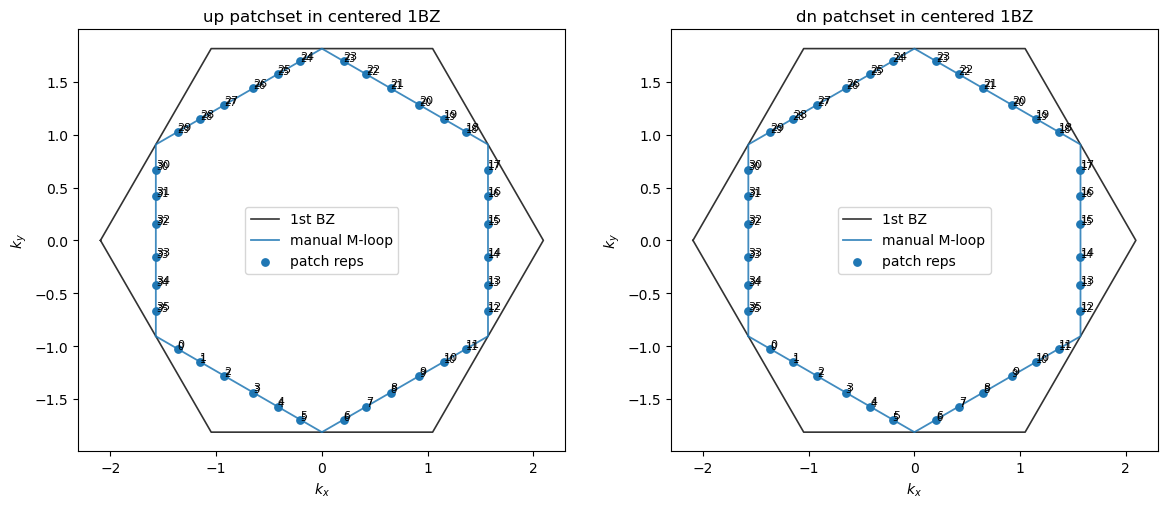

In [31]:
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1
model = noninteracting.KagomeKaneMeleSOC(dict(t=1.0, l1=0.0,l2=0), spin=True, B=None)

# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 7
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"


# ============================================================
# build the final default patchsets for the whole pipeline
# ============================================================
PATCHSETS = build_tr_adapted_patchsets(
    model,
    UP_SLICE,
    DN_SLICE,
    LOCAL_BAND_INDEX,
)

# optional sanity check
defect = pp_triplet_gauge_defect(PATCHSETS)
print("pairing gauge defect max =", np.max(np.abs(defect)))
print("pairing gauge defect fro =", np.linalg.norm(defect))

# ------------------------------------------------------------
# basic sanity: centered 1BZ patch plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    patching.plot_patchset(
        PATCHSETS[spin],
        ax=ax,
        show_contour=True,
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in PATCHSETS[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} patchset in centered 1BZ")

plt.tight_layout()
plt.show()

# Model

CASE = U_only  | U = 0.0  V = 10
T_START, T_STOP, NFREQ, NSTEPS = 5.0 0.05 50 600
NPATCH = 36
diagnosis_Qs:
  Q0 = (0.000000, 0.000000)
  Q1 = (-1.570796, -0.906900)
  Q2 = (0.000000, -1.813799)
  Q3 = (-1.570796, 0.906900)

solver built.
temperature path length = 600
initial channel norm    = 19.965521370960513
solver.patch_measure_mode = length_over_vf_soft

=== bare (initial) sign-aware kernel metrics ===


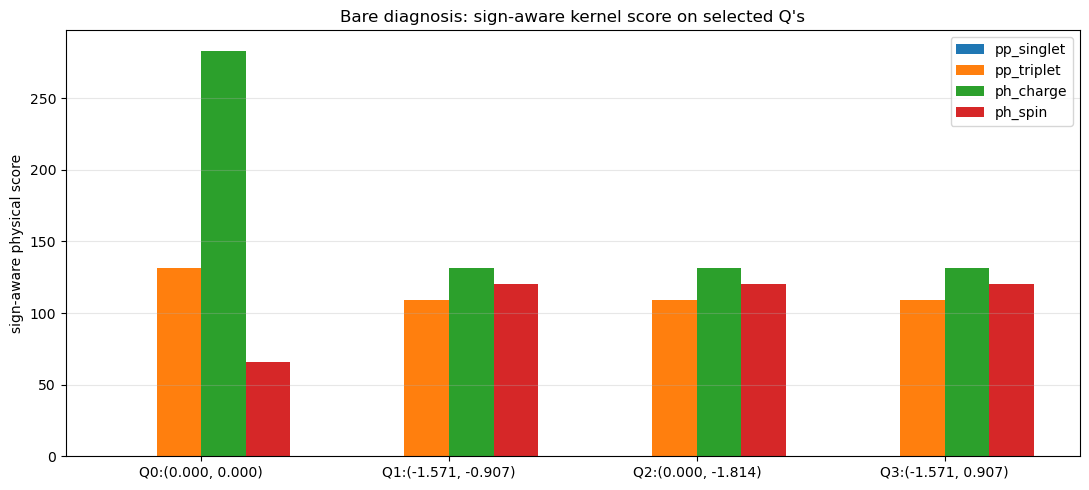


=== bare (initial) physical instability metrics ===


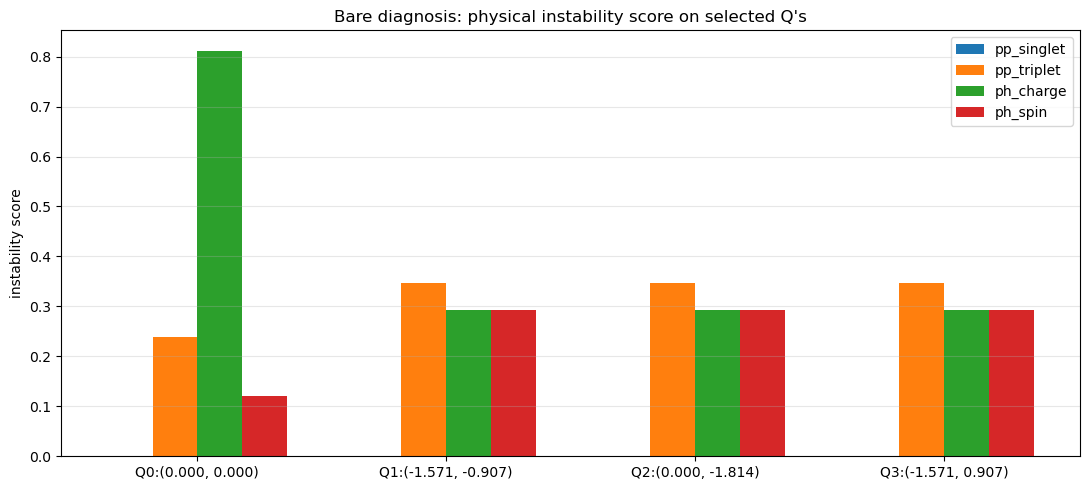

In [11]:
# ============================================================
# Choose interaction case
# ============================================================
CASE = "U_only"   # "U_only" or "V_only"

if CASE == "U_only":
    U_TEST, V_TEST = 0., 10
# elif CASE == "V_only":
#     U_TEST, V_TEST = 0.0, 10.0
else:
    raise ValueError("CASE must be 'U_only' or 'V_only'")


# ============================================================
# Basic diagnosis setup
# ============================================================
T_START = 5.0
T_STOP  = 0.05
NFREQ   = 50
NSTEPS  = 600

# Selected transfer momenta
M6 = patching.exact_M6_points_1bz(model)
diagnosis_Qs = [
    np.array([0.0, 0.0]),
    np.array(M6[0], dtype=float),
    np.array(M6[1], dtype=float),
    np.array(M6[-1], dtype=float),
]

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("NPATCH =", PATCHSETS["up"].Npatch)
print("diagnosis_Qs:")
for i, q in enumerate(diagnosis_Qs):
    print(f"  Q{i} = {fmt_q(q, nd=6)}")


# ============================================================
# Build bare interaction + bare solver
# ============================================================
bare_int = interaction.BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)
bare_sz0 = frg_flow.BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = frg_flow.FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,

    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,

    # lenient integrator setup for exploration
    max_relative_update=5.0,
    min_substep_fraction=1.0 ,
    channel_divergence_threshold=1e10,

    diagnosis_Qs=diagnosis_Qs,
    diagnosis_score_threshold=None,
    diagnosis_landau_F=False,

    # current flow measure
    patch_measure_mode="length_over_vf_soft",              # change here later if needed
    patch_measure_soft_vf_eps=1e-8,
    patch_measure_normalize_mean=False,
)

print("\nsolver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm    =", solver.state.channel_norm())
print("solver.patch_measure_mode =", getattr(solver, "patch_measure_mode", None))

# ============================================================
# Bare sign-aware kernel metrics
# ============================================================
builder0 = build_builder_from_solver(solver, Landau_F=False)
df_signaware_bare, signaware_store = evaluate_signaware_selected_Qs(
    builder0,
    diagnosis_Qs,
    landau_F=False,
)

print("\n=== bare (initial) sign-aware kernel metrics ===")
# display(df_signaware_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_signaware_bare,
    value_col="physical_score",
    title="Bare diagnosis: sign-aware kernel score on selected Q's",
    ylabel="sign-aware physical score",
)

best_signaware_bare = leading_row_from_df(df_signaware_bare, "physical_score")
# print("\n=== bare sign-aware leader ===")
# print("channel :", best_signaware_bare["channel"])
# print("Q       :", fmt_q(best_signaware_bare["Q"], nd=6))
# print("score   :", f"{best_signaware_bare['physical_score']:.12e}")
# print("chosen  :", best_signaware_bare["chosen_sign"], f"{best_signaware_bare['chosen_eval']:.12e}")


# ============================================================
# Bare physical instability diagnosis
# ============================================================
df_instab_bare, instab_store = evaluate_instability_selected_Qs(
    builder0,
    solver,
    diagnosis_Qs,
    temperature=T_START,          # use initial T
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
)

print("\n=== bare (initial) physical instability metrics ===")
# display(df_instab_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_instab_bare,
    value_col="score",
    title="Bare diagnosis: physical instability score on selected Q's",
    ylabel="instability score",
)

best_instab_bare = leading_row_from_df(df_instab_bare, "score")
# print("\n=== bare physical-instability leader ===")
# print("channel :", best_instab_bare["channel"])
# print("Q       :", fmt_q(best_instab_bare["Q"], nd=6))
# print("score   :", f"{best_instab_bare['score']:.12e}")
# print("eval    :", f"{best_instab_bare['leading_eval']:.12e}")
# print("bubble  :", best_instab_bare["bubble_source"])
# print("proj    :", best_instab_bare["projection_name"])

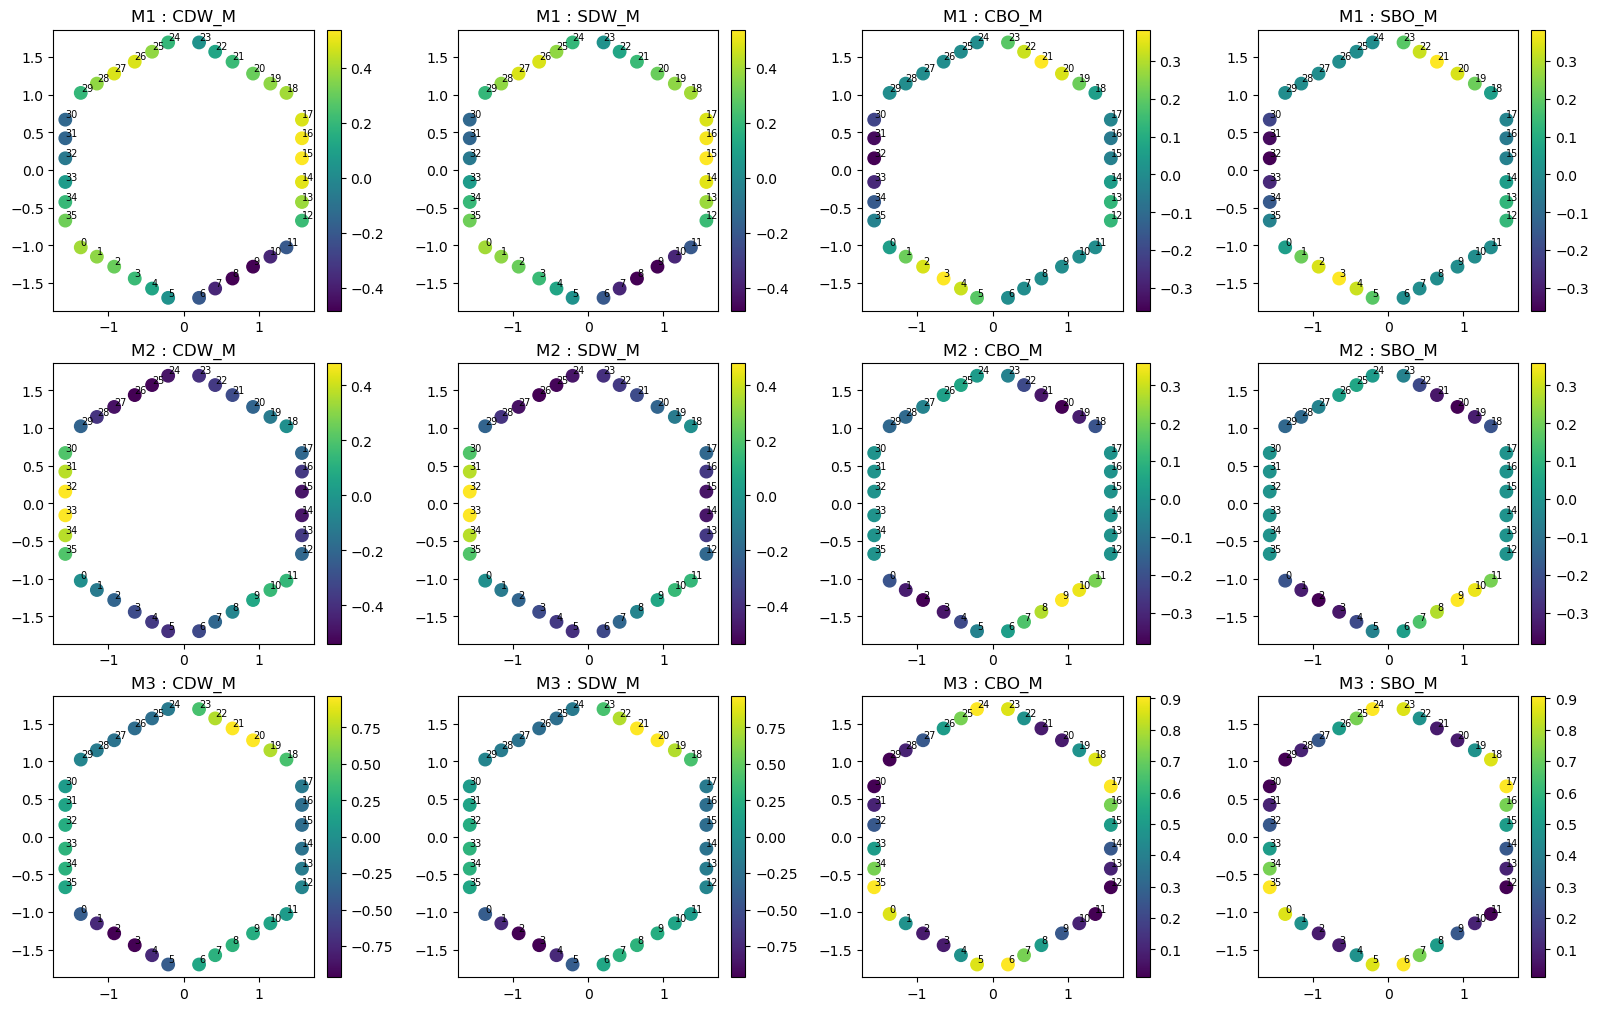

In [62]:
# ============================================================
# Cell 7: visualize the four Q=M candidate vectors on patches
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)

patch_k = np.asarray(patchset_up.patch_k, dtype=float)
families = ["CDW_M", "SDW_M", "CBO_M", "SBO_M"]

for i, blk in enumerate(["M1", "M2", "M3"]):
    for j, fam in enumerate(families):
        ax = axes[i, j]
        vec = np.asarray(qm_candidates[blk][fam], dtype=complex)

        sc = ax.scatter(
            patch_k[:, 0], patch_k[:, 1],
            c=np.real(vec),
            s=80,
        )
        for p, k in enumerate(patch_k):
            ax.text(k[0], k[1], str(p), fontsize=7, ha="left", va="bottom")

        ax.set_title(f"{blk} : {fam}")
        ax.set_aspect("equal")
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

plt.show()

In [15]:
# ============================================================
# Cell 1: visualize all ph-imaginary current candidates
#   - left: real-space schematic current pattern
#   - right: patch-space form factor on FS patches
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import pandas as pd

import candidate_diagnosis_imag as cdi

# ------------------------------------------------------------
# Required notebook variables
# ------------------------------------------------------------
# model
# PATCHSETS
# UP_SLICE
# LOCAL_BAND_INDEX
# QMs = [QM1, QM2, QM3]   or diagnosis_Qs[1:4]

if "QMs" not in globals():
    if "diagnosis_Qs" in globals() and len(diagnosis_Qs) >= 4:
        QMs = [np.asarray(diagnosis_Qs[i], dtype=float) for i in range(1, 4)]
    else:
        raise RuntimeError("Please define QMs = [QM1, QM2, QM3].")

patchset_up = PATCHSETS["up"]

# ------------------------------------------------------------
# Which families to visualize
# ------------------------------------------------------------
families_q0 = [
    "LC_Q0_NAGAOSA",
    "LC_Q0_FLOWA",
    "LC_Q0_FLOWB",
    "SLC_Q0_NAGAOSA",
    "SLC_Q0_FLOWA",
    "SLC_Q0_FLOWB",
]

families_m = [
    "LC_M_PHI1",
    "LC_M_PHI2",
    "LC_M_PHI3",
    "SLC_M_PHI1",
    "SLC_M_PHI2",
    "SLC_M_PHI3",
]

# ------------------------------------------------------------
# Build all candidates
# ------------------------------------------------------------
imag_blocks = {"Q0": {}}
for fam in families_q0:
    imag_blocks["Q0"][fam] = cdi.build_ph_imag_family(
        fam,
        model=model,
        patchset=patchset_up,
        band_index=LOCAL_BAND_INDEX,
        Q=np.zeros(2),
        spin_slice=UP_SLICE,
        use_patchset_eigvec_at_k=True,
    )

for i, QM in enumerate(QMs):
    blk = f"M{i+1}"
    imag_blocks[blk] = {}
    for fam in families_m:
        imag_blocks[blk][fam] = cdi.build_ph_imag_family(
            fam,
            model=model,
            patchset=patchset_up,
            band_index=LOCAL_BAND_INDEX,
            Q=np.asarray(QM, dtype=float),
            m_index=i,
            spin_slice=UP_SLICE,
            use_patchset_eigvec_at_k=True,
        )

# ------------------------------------------------------------
# Helpers: operator matrices for schematic current pattern
# ------------------------------------------------------------
A, B, C = 0, 1, 2

# simple kagome triangle coordinates within one unit cell
rA = np.array([0.0, 0.0])
rB = np.array([1.0, 0.0])
rC = np.array([0.5, np.sqrt(3)/2])
site_pos = {A: rA, B: rB, C: rC}
site_label = {A: "A", B: "B", C: "C"}

# lattice translations for a 2x2 schematic
a1 = np.array([1.6, 0.0])
a2 = np.array([0.8, 1.385640646])   # ~ (1/2, sqrt(3)/2) scaled

def current_matrix(pair, sign=+1.0):
    i, j = pair
    M = np.zeros((3, 3), dtype=complex)
    M[i, j] = -1j * sign
    M[j, i] = +1j * sign
    return M

L2 = current_matrix((A, B), sign=+1.0)
L5 = current_matrix((A, C), sign=+1.0)
L7 = current_matrix((B, C), sign=+1.0)

def operator_from_builder_key(builder_key):
    if builder_key == "lc_q0_nagaosa":
        return L2 - L5 + L7
    if builder_key == "lc_q0_flowa":
        return L2 + L5 + L7
    if builder_key.startswith("lc_q0_flowb_"):
        idx = int(builder_key.split("_")[-1])
        return [L2, L5, L7][idx]
    if builder_key == "lc_m_phi1":
        return L2 - L5 + L7
    if builder_key == "lc_m_phi2":
        return L5 + L7
    if builder_key == "lc_m_phi3":
        return L2 + L5
    raise ValueError(f"Unknown builder_key = {builder_key}")

def draw_current_bond(ax, p1, p2, weight, color="tab:red", scale=0.25):
    """
    weight > 0: arrow p1 -> p2
    weight < 0: arrow p2 -> p1
    """
    if abs(weight) < 1e-12:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="lightgray", lw=1.0, zorder=1)
        return

    src, dst = (p1, p2) if weight > 0 else (p2, p1)
    arrow = FancyArrowPatch(
        src, dst,
        arrowstyle='-|>',
        mutation_scale=10 + 15*min(abs(weight), 1.0),
        linewidth=1.5 + 2.5*min(abs(weight), 1.0),
        color=color,
        alpha=0.9,
        shrinkA=10,
        shrinkB=10,
        zorder=3,
    )
    ax.add_patch(arrow)

def draw_unitcell_sites(ax, shift=np.zeros(2)):
    for s, r in site_pos.items():
        rr = r + shift
        ax.scatter(rr[0], rr[1], s=80, color="black", zorder=4)
        ax.text(rr[0]+0.03, rr[1]+0.03, site_label[s], fontsize=8)

def draw_current_pattern_q0(ax, O, title=""):
    ax.set_title(title, fontsize=10)
    shift = np.zeros(2)
    draw_unitcell_sites(ax, shift)
    pairs = [(A,B), (A,C), (B,C)]
    for i, j in pairs:
        p1 = site_pos[i] + shift
        p2 = site_pos[j] + shift
        # for imaginary antisymmetric current matrix: physical orientation from imag part
        w = np.imag(O[i, j])
        draw_current_bond(ax, p1, p2, w)

    ax.set_aspect("equal")
    ax.axis("off")

def draw_current_pattern_qm(ax, O, Q, title=""):
    ax.set_title(title, fontsize=10)
    # 2x2 schematic using cos(Q·R) amplitude
    cells = [(0,0), (1,0), (0,1), (1,1)]
    pairs = [(A,B), (A,C), (B,C)]

    for n1, n2 in cells:
        R = n1*a1 + n2*a2
        amp = np.cos(np.dot(Q, R))  # schematic single-Q modulation
        draw_unitcell_sites(ax, R)
        for i, j in pairs:
            p1 = site_pos[i] + R
            p2 = site_pos[j] + R
            w = amp * np.imag(O[i, j])
            draw_current_bond(ax, p1, p2, w)

    ax.set_aspect("equal")
    ax.axis("off")

def plot_form_factor(ax, cand, title=""):
    ks = np.asarray(cand.patch_k, dtype=float)
    v = np.asarray(cand.vector_patch, dtype=complex)
    sc = ax.scatter(
        ks[:, 0], ks[:, 1],
        c=np.imag(v),
        s=70,
        edgecolor="k",
    )
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=7, ha="left", va="bottom")
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.set_xlabel("$k_x$")
    ax.set_ylabel("$k_y$")
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# ------------------------------------------------------------
# Make one figure per block
# ------------------------------------------------------------
for block_name, fams in imag_blocks.items():
    nrows = len(fams)
    fig, axes = plt.subplots(nrows, 2, figsize=(10, 3.0*nrows), constrained_layout=True)
    if nrows == 1:
        axes = np.array([axes])

    for row, (fam, cand_list) in enumerate(fams.items()):
        # use the first member as representative for 1D families;
        # flow-b has 3 members; we plot each member separately below if needed
        if len(cand_list) == 1:
            reps = cand_list
        else:
            reps = cand_list

        # if multi-member family, show only the first in this summary figure
        cand = reps[0]
        O = operator_from_builder_key(cand.spec.builder_key)

        left_ax  = axes[row, 0]
        right_ax = axes[row, 1]

        if block_name == "Q0":
            draw_current_pattern_q0(left_ax, O, title=f"{block_name} : {fam}")
        else:
            draw_current_pattern_qm(left_ax, O, cand.Q, title=f"{block_name} : {fam}")

        plot_form_factor(right_ax, cand, title=f"{block_name} : {cand.spec.name}")

    plt.show()

# ------------------------------------------------------------
# Optional: for FLOWB family, inspect all members separately
# ------------------------------------------------------------
for fam in ["LC_Q0_FLOWB", "SLC_Q0_FLOWB"]:
    cands = imag_blocks["Q0"][fam]
    fig, axes = plt.subplots(len(cands), 2, figsize=(10, 3*len(cands)), constrained_layout=True)
    if len(cands) == 1:
        axes = np.array([axes])

    for i, cand in enumerate(cands):
        O = operator_from_builder_key(cand.spec.builder_key)
        draw_current_pattern_q0(axes[i, 0], O, title=cand.spec.name)
        plot_form_factor(axes[i, 1], cand, title=cand.spec.name)

    plt.show()

RuntimeError: Please define QMs = [QM1, QM2, QM3].

In [16]:
# ============================================================
# Cell 1: notebook-local Q=0 current builders (do NOT edit python file yet)
#   - supports MODEL_KIND = "nagaosa" or "kanemele_l1"
#   - Q=0 only
#   - separates:
#       (i) real-space current class
#       (ii) patch-space band-projected form factor
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import noninteracting as nonint
import patching
import candidate_diagnosis_v2 as cdr_ph

# ------------------------------------------------------------
# User controls
# ------------------------------------------------------------
MODEL_KIND = "nagaosa"         # "nagaosa" or "kanemele_l1"
TARGET_FILLING = 5.0 / 12.0
BAND_INDEX = 1
POINTS_PER_EDGE = 8            # 8 -> 48 patches
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"
REMOVE_DUPLICATE_M_MODG = False
PROJECT_TO_FS_POINTS = True

# model parameters
T_HOP = 1.0
PHI_EVAL = 0.30     # for KagomeNagaosa
L1_EVAL  = 0.30     # for KagomeKaneMeleSOC
L2_EVAL  = 0.00
EF_GRID_N = 140

# ------------------------------------------------------------
# Lightweight dataclasses
# ------------------------------------------------------------
@dataclass(frozen=True)
class Q0CurrentSpec:
    name: str
    family: str
    spin_structure: str    # "charge" or "spin"
    irrep_label: str
    builder_key: str
    notes: Tuple[str, ...] = field(default_factory=tuple)

@dataclass
class Q0CurrentCandidate:
    spec: Q0CurrentSpec
    patch_k: np.ndarray
    vector_patch: np.ndarray
    model_kind: str
    operator_label: str

# ------------------------------------------------------------
# Model / patchset construction
# ------------------------------------------------------------
KagomeNagaosa = nonint.KagomeNagaosa
KagomeKaneMeleSOC = nonint.KagomeKaneMeleSOC
build_exactM_patchset = patching.build_exactM_patchset
hex_bz_vertices = patching.hex_bz_vertices

if MODEL_KIND.lower() == "nagaosa":
    model_q0 = KagomeNagaosa(
        {"t": T_HOP, "phi": PHI_EVAL},
        spin=False,
        B=None,
    )
    coupling_name = "phi"
    coupling_value = PHI_EVAL

elif MODEL_KIND.lower() == "kanemele_l1":
    model_q0 = KagomeKaneMeleSOC(
        {"t": T_HOP, "l1": L1_EVAL, "l2": L2_EVAL},
        spin=False,
        B=None,
    )
    coupling_name = "l1"
    coupling_value = L1_EVAL

else:
    raise ValueError("MODEL_KIND must be 'nagaosa' or 'kanemele_l1'.")

# mu_q0 = model_q0.EF_from_filling(TARGET_FILLING, N=EF_GRID_N)
mu_q0 = 0
patchset_q0 = build_exactM_patchset(
    model_q0,
    slice(0, 3),              # spinless / single-spin 3x3 block
    BAND_INDEX,
    points_per_edge=POINTS_PER_EDGE,
    remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
    gauge_fix=GAUGE_FIX,
    close_loop_gauge=CLOSE_LOOP_GAUGE,
    gauge_anchor=GAUGE_ANCHOR,
    project_to_fs_points=PROJECT_TO_FS_POINTS,
    mu=mu_q0,
)

print(f"MODEL_KIND      = {MODEL_KIND}")
print(f"coupling        = {coupling_name} = {coupling_value}")
print(f"TARGET_FILLING  = {TARGET_FILLING:.8f}")
print(f"mu              = {mu_q0:.10f}")
print(f"Npatch          = {patchset_q0.Npatch}")
print(f"band_index      = {patchset_q0.band_index}")

# ------------------------------------------------------------
# Current operators
# ------------------------------------------------------------
def _cos_bond_operator(model, kx, ky, eta_ab, eta_ac, eta_bc, prefactor=1.0):
    """
    Generic Q=0 NN-current-like Hermitian operator in the 3x3 sublattice block:
        O_ab ~ i * eta_ab * cos(k·delta1), etc.
    This is NOT claimed to be a microscopic derivative operator unless explicitly so.
    """
    kvec = np.array([kx, ky], dtype=float)
    c1 = np.cos(np.dot(model.delta1, kvec))
    c2 = np.cos(np.dot(model.delta2, kvec))
    c3 = np.cos(np.dot(model.delta3, kvec))

    O = np.array(
        [
            [0.0,                     1j * prefactor * eta_ab * c1,   1j * prefactor * eta_ac * c2],
            [-1j * prefactor * eta_ab * c1, 0.0,                      1j * prefactor * eta_bc * c3],
            [-1j * prefactor * eta_ac * c2, -1j * prefactor * eta_bc * c3, 0.0],
        ],
        dtype=complex,
    )
    O = 0.5 * (O + O.conjugate().T)
    return O

def _dH_dphi_nagaosa(model, kx, ky):
    """
    Exact microscopic current operator for the spinless KagomeNagaosa model:
        O(k) = dH/dphi
    This should reproduce your previous 'figure 3' logic.
    """
    t = model.parameters["t"]
    phi = model.parameters["phi"]
    kvec = np.array([kx, ky], dtype=float)

    c1 = np.cos(np.dot(model.delta1, kvec))
    c2 = np.cos(np.dot(model.delta2, kvec))
    c3 = np.cos(np.dot(model.delta3, kvec))

    AB = -2.0 * t * np.exp(1j * phi / 3.0) * c1
    AC = -2.0 * t * np.exp(-1j * phi / 3.0) * c2
    BC = -2.0 * t * np.exp(1j * phi / 3.0) * c3

    dAB = (1j / 3.0) * AB
    dAC = (-1j / 3.0) * AC
    dBC = (1j / 3.0) * BC

    O = np.array(
        [
            [0.0,               dAB,               dAC],
            [np.conjugate(dAB), 0.0,               dBC],
            [np.conjugate(dAC), np.conjugate(dBC), 0.0],
        ],
        dtype=complex,
    )
    O = 0.5 * (O + O.conjugate().T)
    return O

def _dH_dl1_kanemele(model, kx, ky, s=+1):
    """
    Exact microscopic current-like operator for spinless KagomeKaneMeleSOC:
        O(k) = dH/dl1
    """
    f1, f2, f3, _, _, _ = model.f(kx, ky)
    O = np.array(
        [
            [0.0,            1j * s * f1,   -1j * s * f2],
            [-1j * s * f1,   0.0,            1j * s * f3],
            [1j * s * f2,   -1j * s * f3,    0.0],
        ],
        dtype=complex,
    )
    O = 0.5 * (O + O.conjugate().T)
    return O

def q0_current_operator(model, kx, ky, builder_key):
    """
    Returns the 3x3 Hermitian operator O(k) used to define
        f(k) = <u(k)| O(k) |u(k)>
    """
    # Nagaosa: use exact microscopic operator whenever possible
    if builder_key == "lc_q0_nagaosa":
        if MODEL_KIND.lower() == "nagaosa":
            return _dH_dphi_nagaosa(model, kx, ky)
        elif MODEL_KIND.lower() == "kanemele_l1":
            # same 'most physical' choice for KM-SOC current-like operator
            return _dH_dl1_kanemele(model, kx, ky, s=+1)

    # Flow-a / Flow-b: symmetry-pattern operators, not exact derivatives
    if builder_key == "lc_q0_flowa":
        # all three bond directions active with same circulation sense
        return _cos_bond_operator(model, kx, ky, +1.0, +1.0, +1.0, prefactor=2.0)

    if builder_key == "lc_q0_flowb_0":
        return _cos_bond_operator(model, kx, ky, +1.0, 0.0, 0.0, prefactor=2.0)
    if builder_key == "lc_q0_flowb_1":
        return _cos_bond_operator(model, kx, ky, 0.0, +1.0, 0.0, prefactor=2.0)
    if builder_key == "lc_q0_flowb_2":
        return _cos_bond_operator(model, kx, ky, 0.0, 0.0, +1.0, prefactor=2.0)

    raise ValueError(f"Unknown builder_key = {builder_key}")

# ------------------------------------------------------------
# Candidate library
# ------------------------------------------------------------
def q0_current_library():
    return {
        "LC_Q0_NAGAOSA": [
            Q0CurrentSpec(
                name="LC_Q0_NAGAOSA",
                family="LC_Q0_NAGAOSA",
                spin_structure="charge",
                irrep_label="A?",
                builder_key="lc_q0_nagaosa",
                notes=("Q=0 Nagaosa-like loop current",),
            )
        ],
        "LC_Q0_FLOWA": [
            Q0CurrentSpec(
                name="LC_Q0_FLOWA",
                family="LC_Q0_FLOWA",
                spin_structure="charge",
                irrep_label="A?",
                builder_key="lc_q0_flowa",
                notes=("Q=0 flow-a current class",),
            )
        ],
        "LC_Q0_FLOWB": [
            Q0CurrentSpec(
                name="LC_Q0_FLOWB_0",
                family="LC_Q0_FLOWB",
                spin_structure="charge",
                irrep_label="dir",
                builder_key="lc_q0_flowb_0",
                notes=("Q=0 flow-b, direction 0",),
            ),
            Q0CurrentSpec(
                name="LC_Q0_FLOWB_1",
                family="LC_Q0_FLOWB",
                spin_structure="charge",
                irrep_label="dir",
                builder_key="lc_q0_flowb_1",
                notes=("Q=0 flow-b, direction 1",),
            ),
            Q0CurrentSpec(
                name="LC_Q0_FLOWB_2",
                family="LC_Q0_FLOWB",
                spin_structure="charge",
                irrep_label="dir",
                builder_key="lc_q0_flowb_2",
                notes=("Q=0 flow-b, direction 2",),
            ),
        ],
    }

def band_form_factor_on_patch(model, patchset, band_index, builder_key):
    patch_k = np.asarray(patchset.patch_k, dtype=float)
    patch_ff = np.zeros(len(patch_k), dtype=float)
    for i, (kx, ky) in enumerate(patch_k):
        evals, evecs = model.eigenstate(float(kx), float(ky))
        u = np.asarray(evecs[:, band_index], dtype=complex)
        O = q0_current_operator(model, float(kx), float(ky), builder_key)
        val = np.vdot(u, O @ u)
        val = np.real_if_close(val, tol=1000)
        patch_ff[i] = float(np.real(val))
    return patch_ff

def build_q0_current_family(model, patchset, band_index, family):
    lib = q0_current_library()
    specs = lib[family]
    out = []
    for spec in specs:
        vec = band_form_factor_on_patch(model, patchset, band_index, spec.builder_key)
        out.append(Q0CurrentCandidate(
            spec=spec,
            patch_k=np.asarray(patchset.patch_k, dtype=float),
            vector_patch=np.asarray(vec, dtype=complex),
            model_kind=MODEL_KIND,
            operator_label=spec.builder_key,
        ))
    return out

# ------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------
A, B, C = 0, 1, 2
rA = np.array([0.0, 0.0])
rB = np.array([1.0, 0.0])
rC = np.array([0.5, np.sqrt(3)/2])
site_pos = {A: rA, B: rB, C: rC}
site_label = {A: "A", B: "B", C: "C"}

def _draw_current_bond(ax, p1, p2, weight, color="tab:red"):
    if abs(weight) < 1e-14:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="lightgray", lw=1.0, zorder=1)
        return
    src, dst = (p1, p2) if weight > 0 else (p2, p1)
    arrow = FancyArrowPatch(
        src, dst,
        arrowstyle='-|>',
        mutation_scale=16,
        linewidth=2.2,
        color=color,
        alpha=0.9,
        shrinkA=10,
        shrinkB=10,
        zorder=3,
    )
    ax.add_patch(arrow)

def draw_q0_current_class(ax, family, member_index=0, title=""):
    ax.set_title(title, fontsize=10)

    # schematic class-level arrows
    for s, r in site_pos.items():
        ax.scatter(r[0], r[1], s=40, color="black", zorder=4)
        ax.text(r[0]+0.03, r[1]+0.03, site_label[s], fontsize=8)

    if family == "LC_Q0_NAGAOSA":
        # oriented circulation on all three bonds
        pairs = [((A,B), +1), ((B,C), -1), ((C,A), -1)]
    elif family == "LC_Q0_FLOWA":
        pairs = [((A,B), +1), ((A,C), +1), ((B,C), +1)]
    elif family == "LC_Q0_FLOWB":
        opts = [
            [((A,B), +1)],
            [((A,C), +1)],
            [((B,C), +1)],
        ]
        pairs = opts[member_index]
    else:
        pairs = []

    all_pairs = [(A,B), (A,C), (B,C)]
    active = set(tuple(sorted(p)) for p, _ in pairs)

    # faint background bonds
    for i, j in all_pairs:
        p1, p2 = site_pos[i], site_pos[j]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="lightgray", lw=1.0, zorder=1)

    for (i, j), sgn in pairs:
        p1, p2 = site_pos[i], site_pos[j]
        _draw_current_bond(ax, p1, p2, sgn)

    ax.set_aspect("equal")
    ax.axis("off")

def _normalize(v):
    v = np.asarray(v, dtype=complex).reshape(-1)
    n = np.linalg.norm(v)
    if n == 0:
        return np.zeros_like(v)
    return v / n
    
def _patch_angles_from_patchset(patchset):
    ks = np.asarray(patchset.patch_k, dtype=float)
    theta = np.arctan2(ks[:, 1], ks[:, 0])
    return ks, theta

def _orthonormalize_templates(vecs, tol=1e-12):
    out = []
    for v in vecs:
        w = np.asarray(v, dtype=complex).copy()
        for b in out:
            w = w - np.vdot(b, w) * b
        nrm = np.linalg.norm(w)
        if nrm > tol:
            out.append(w / nrm)
    return out

def _build_harmonic_subspaces(theta, lmax=8):
    theta = np.asarray(theta, dtype=float)
    N = len(theta)
    subspaces = {}
    raw_templates = []
    L0 = np.ones(N, dtype=float)
    B0 = _orthonormalize_templates([L0])
    subspaces[0] = B0
    raw_templates.append(("l=0 const", _normalize(L0)))
    for l in range(1, lmax + 1):
        c = np.cos(l * theta)
        s = np.sin(l * theta)
        B = _orthonormalize_templates([c, s])
        subspaces[l] = B
        raw_templates.append((f"cos({l}θ)", _normalize(c)))
        raw_templates.append((f"sin({l}θ)", _normalize(s)))
    return subspaces, raw_templates

def _subspace_weight(vec, basis):
    v = _normalize(vec)
    if len(basis) == 0:
        return 0.0
    B = np.column_stack([_normalize(b) for b in basis])
    coeff = B.conjugate().T @ v
    return float(np.real(np.vdot(coeff, coeff)))

def harmonic_summary(cand, lmax=8):
    ks, theta = _patch_angles_from_patchset(patchset_q0)
    v = _normalize(np.asarray(cand.vector_patch, dtype=complex))
    subspaces, raw_harmonics = _build_harmonic_subspaces(theta, lmax=lmax)

    rows_sub = []
    sumw = 0.0
    for l in range(0, lmax + 1):
        w = _subspace_weight(v, subspaces[l])
        sumw += w
        rows_sub.append({"l": l, "subspace_weight": w, "subspace_dim": len(subspaces[l])})
    rows_sub.append({"l": "residual", "subspace_weight": max(0.0, 1.0 - sumw), "subspace_dim": np.nan})

    rows_raw = []
    for label, templ in raw_harmonics:
        rows_raw.append({"template": label, "abs_overlap": float(abs(np.vdot(_normalize(templ), v)))})
    df_raw = pd.DataFrame(rows_raw).sort_values("abs_overlap", ascending=False).reset_index(drop=True)
    df_sub = pd.DataFrame(rows_sub)
    return df_sub, df_raw

MODEL_KIND      = nagaosa
coupling        = phi = 0.3
TARGET_FILLING  = 0.41666667
mu              = 0.0000000000
Npatch          = 48
band_index      = 1


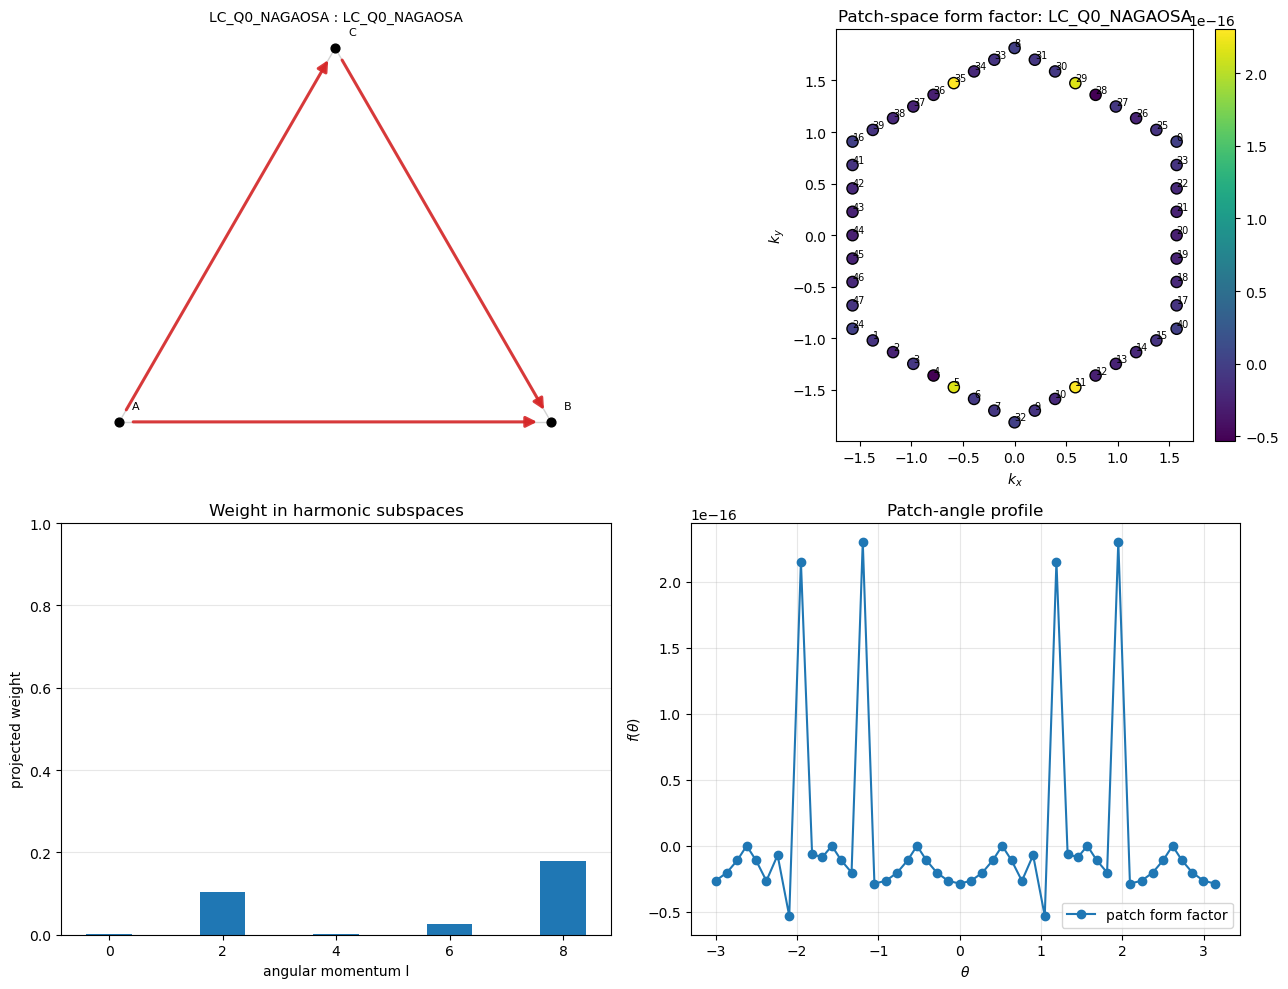


=== LC_Q0_NAGAOSA ===


,l,subspace_weight,subspace_dim
0,0,1.942266e-03,1.0
1,1,1.589268e-34,2.0
2,2,1.036759e-01,2.0
3,3,4.272076e-33,2.0
4,4,1.156283e-03,2.0
5,5,3.131517e-34,2.0
6,6,2.597308e-02,2.0
7,7,1.504407e-32,2.0
8,8,1.778836e-01,2.0
9,residual,6.893689e-01,NaN


,template,abs_overlap
0,cos(8θ),4.214773e-01
1,cos(2θ),3.218118e-01
2,cos(6θ),1.611111e-01
3,l=0 const,4.407115e-02
4,cos(4θ),3.155425e-02
5,sin(8θ),1.550724e-02
6,sin(4θ),1.267329e-02
7,sin(2θ),1.063333e-02
8,sin(6θ),4.037704e-03
9,cos(7θ),1.105909e-16


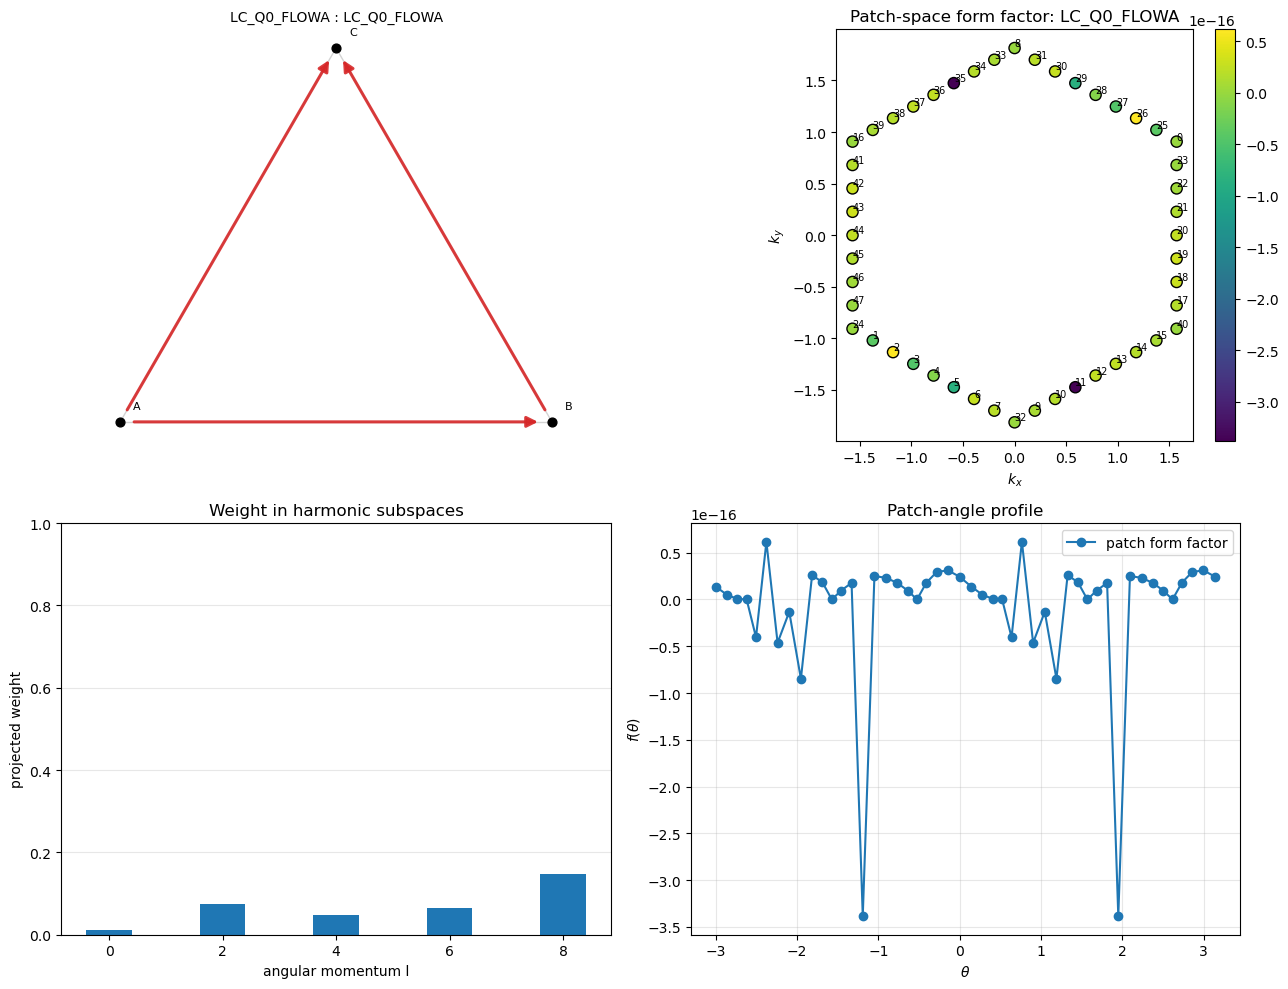


=== LC_Q0_FLOWA ===


,l,subspace_weight,subspace_dim
0,0,1.131942e-02,1.0
1,1,2.091065e-34,2.0
2,2,7.394880e-02,2.0
3,3,1.264769e-32,2.0
4,4,4.827504e-02,2.0
5,5,1.451418e-33,2.0
6,6,6.426008e-02,2.0
7,7,2.374136e-32,2.0
8,8,1.463868e-01,2.0
9,residual,6.558098e-01,NaN


,template,abs_overlap
0,cos(8θ),3.703053e-01
1,cos(2θ),2.695668e-01
2,sin(4θ),2.136052e-01
3,cos(6θ),1.990164e-01
4,sin(6θ),1.570113e-01
5,l=0 const,1.063928e-01
6,sin(8θ),9.623296e-02
7,cos(4θ),5.145736e-02
8,sin(2θ),3.581240e-02
9,cos(7θ),1.097162e-16


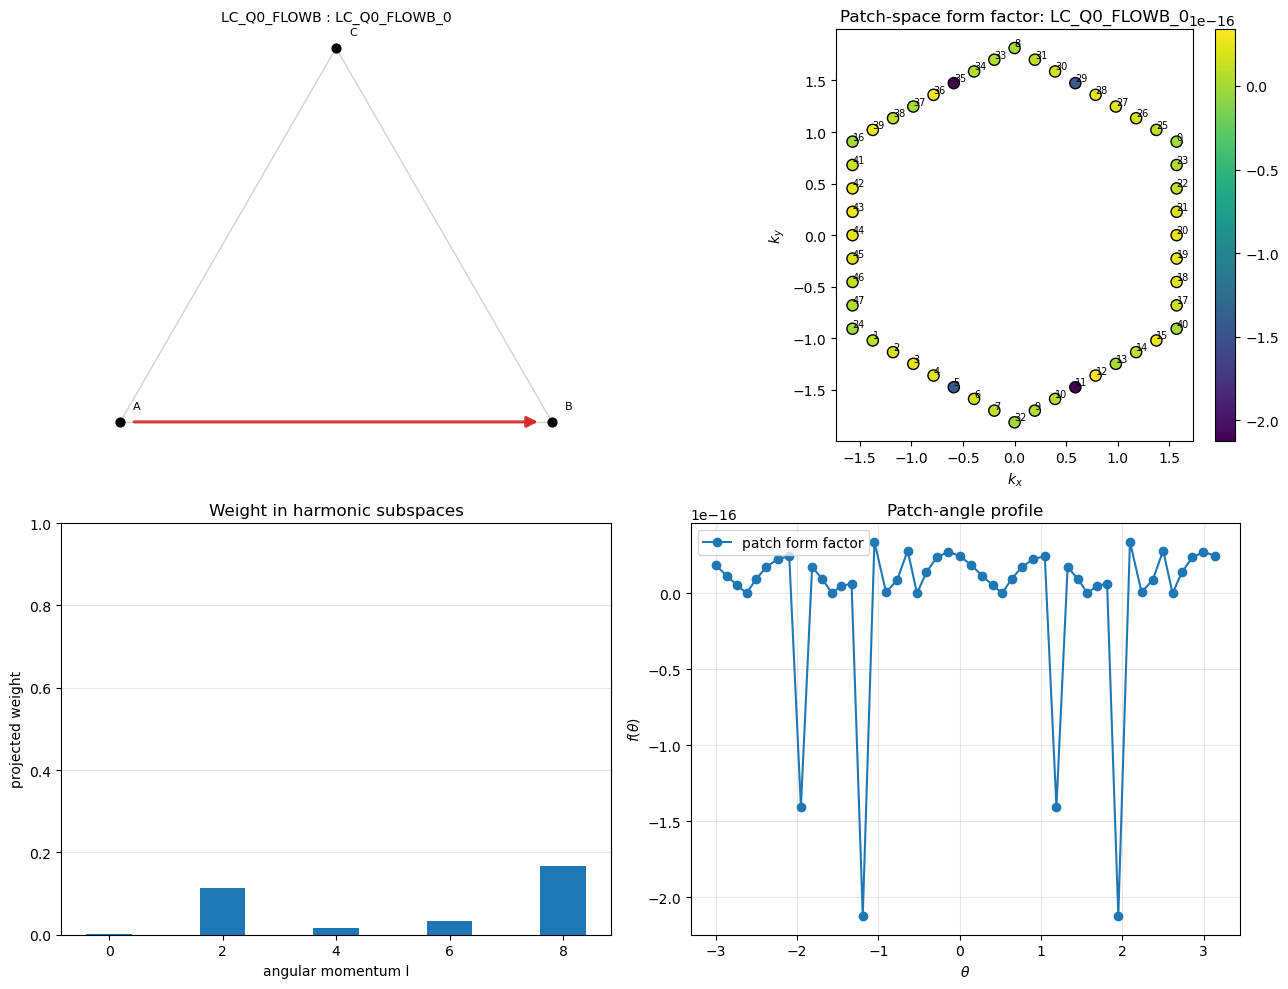


=== LC_Q0_FLOWB_0 ===


,l,subspace_weight,subspace_dim
0,0,1.260277e-03,1.0
1,1,2.155010e-33,2.0
2,2,1.139913e-01,2.0
3,3,1.711755e-33,2.0
4,4,1.695408e-02,2.0
5,5,3.920932e-33,2.0
6,6,3.297678e-02,2.0
7,7,1.196636e-32,2.0
8,8,1.674449e-01,2.0
9,residual,6.673727e-01,NaN


,template,abs_overlap
0,cos(8θ),4.090071e-01
1,cos(2θ),3.343055e-01
2,cos(6θ),1.784110e-01
3,sin(4θ),1.281060e-01
4,sin(2θ),4.723525e-02
5,l=0 const,3.550039e-02
6,sin(6θ),3.385686e-02
7,cos(4θ),2.330113e-02
8,sin(8θ),1.257078e-02
9,cos(7θ),1.176733e-16


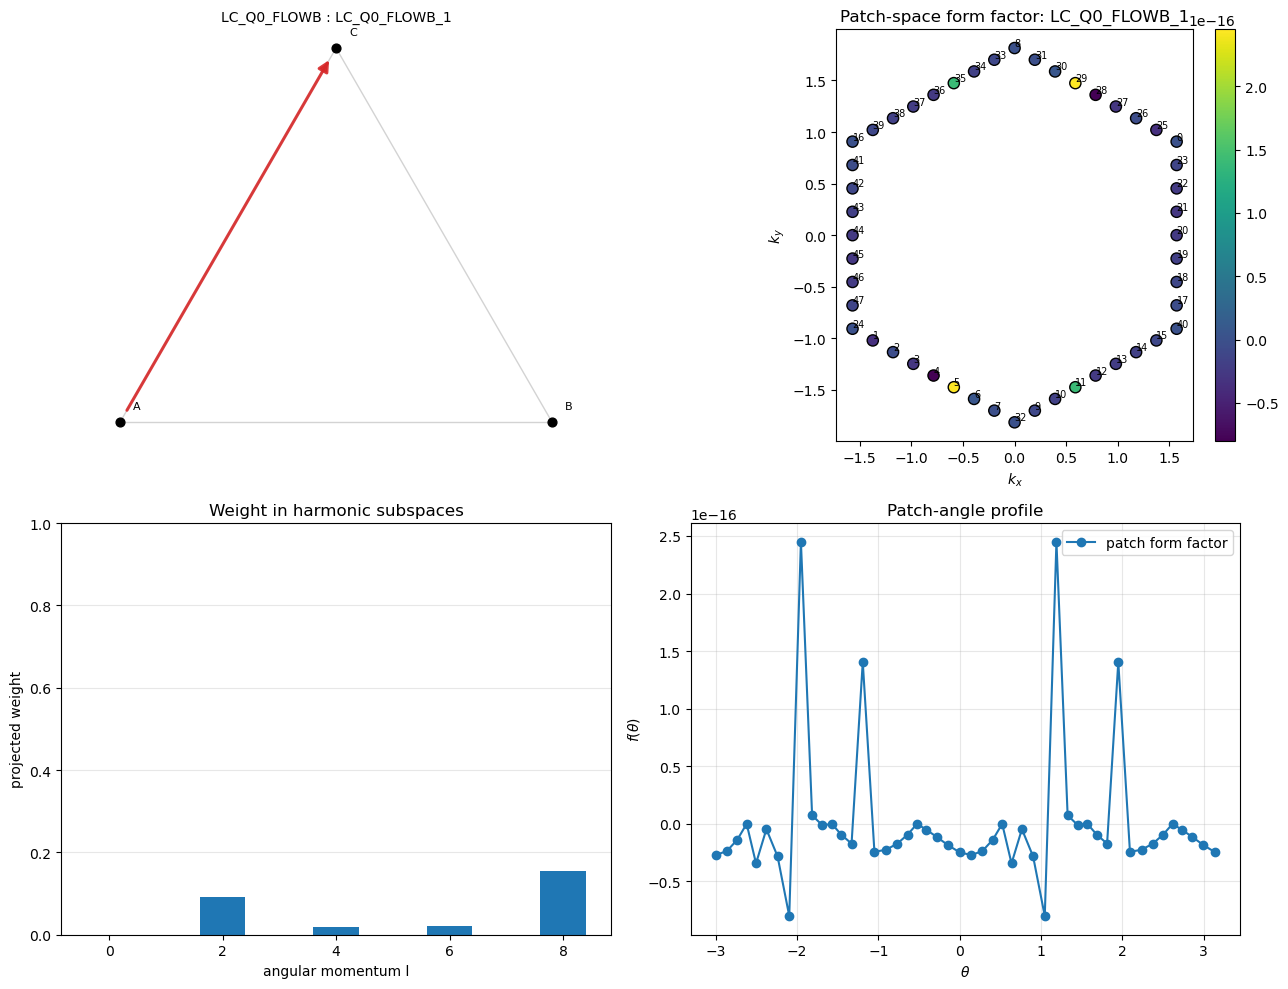


=== LC_Q0_FLOWB_1 ===


,l,subspace_weight,subspace_dim
0,0,1.848099e-04,1.0
1,1,4.004204e-34,2.0
2,2,9.241834e-02,2.0
3,3,2.009625e-33,2.0
4,4,1.793924e-02,2.0
5,5,4.391271e-33,2.0
6,6,2.133021e-02,2.0
7,7,2.946767e-32,2.0
8,8,1.545836e-01,2.0
9,residual,7.135438e-01,NaN


,template,abs_overlap
0,cos(8θ),3.842602e-01
1,cos(2θ),3.039715e-01
2,cos(6θ),1.163048e-01
3,sin(4θ),1.085617e-01
4,sin(6θ),8.833690e-02
5,sin(8θ),8.323248e-02
6,cos(4θ),7.844495e-02
7,l=0 const,1.359448e-02
8,sin(2θ),4.436361e-03
9,cos(7θ),1.226323e-16


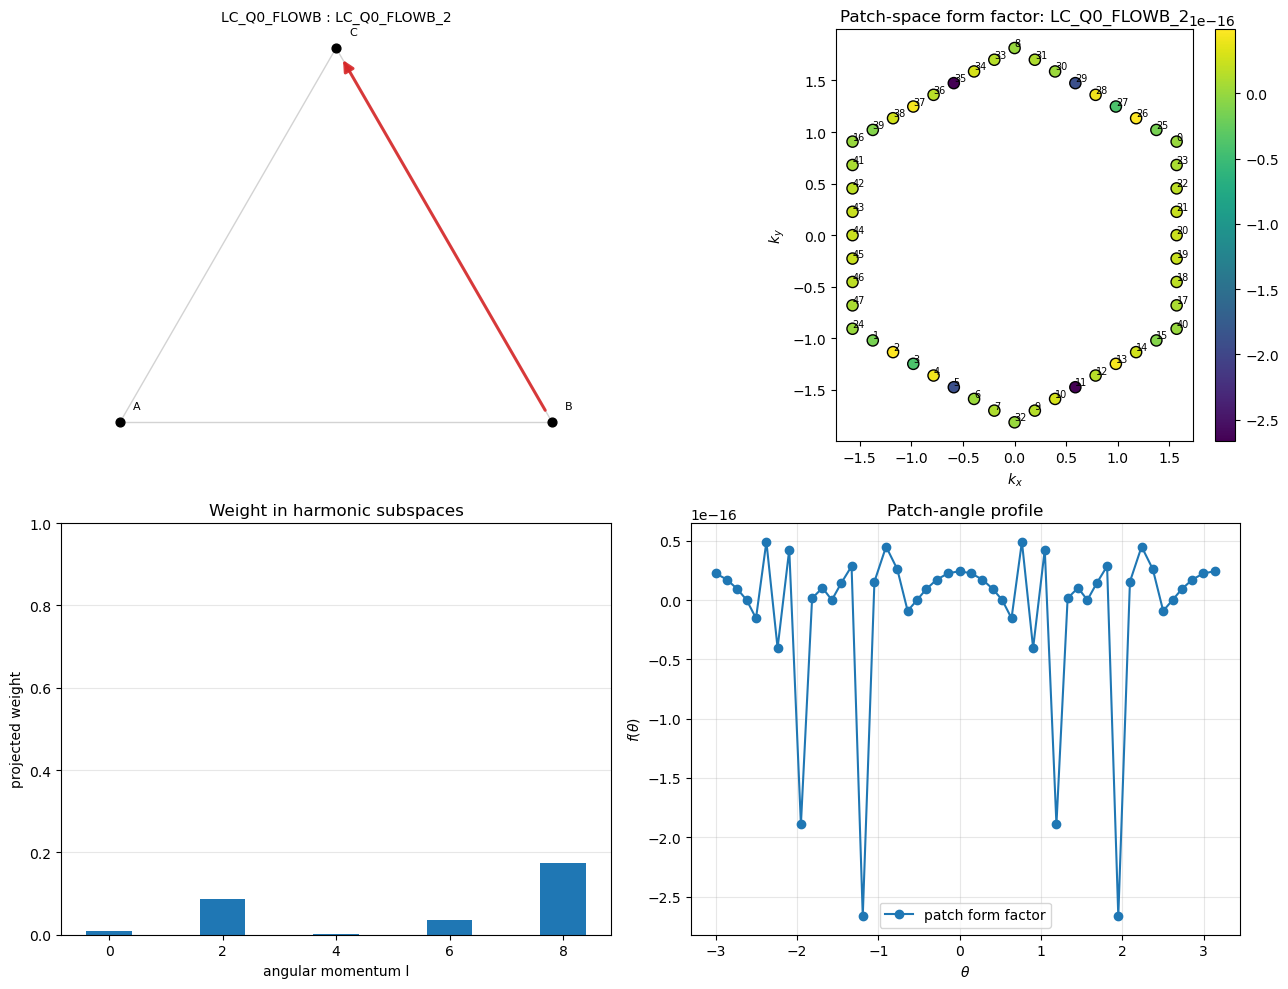


=== LC_Q0_FLOWB_2 ===


,l,subspace_weight,subspace_dim
0,0,9.564807e-03,1.0
1,1,6.767556e-34,2.0
2,2,8.779882e-02,2.0
3,3,4.393528e-33,2.0
4,4,1.083628e-03,2.0
5,5,1.070405e-33,2.0
6,6,3.510415e-02,2.0
7,7,1.251803e-32,2.0
8,8,1.738705e-01,2.0
9,residual,6.925781e-01,NaN


,template,abs_overlap
0,cos(8θ),4.165260e-01
1,cos(2θ),2.962997e-01
2,cos(6θ),1.763953e-01
3,l=0 const,9.779983e-02
4,sin(6θ),6.315742e-02
5,sin(4θ),3.271092e-02
6,sin(8θ),1.940530e-02
7,cos(4θ),3.690964e-03
8,sin(2θ),2.306451e-03
9,cos(7θ),1.263839e-16


right,LC_Q0_FLOWA,LC_Q0_FLOWB_0,LC_Q0_FLOWB_1,LC_Q0_FLOWB_2,LC_Q0_NAGAOSA
left,,,,,
LC_Q0_FLOWA,1.000000,0.893788,0.613327,0.913892,0.836985
LC_Q0_FLOWB_0,0.893788,1.000000,0.870888,0.945600,0.972975
LC_Q0_FLOWB_1,0.613327,0.870888,1.000000,0.860592,0.945373
LC_Q0_FLOWB_2,0.913892,0.945600,0.860592,1.000000,0.971646
LC_Q0_NAGAOSA,0.836985,0.972975,0.945373,0.971646,1.000000


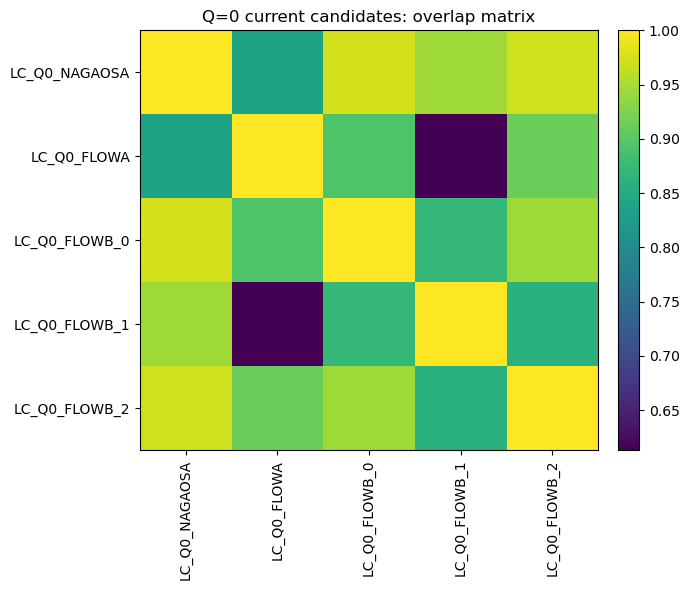

real,FM_Q0,PI_Q0_dx2y2,PI_Q0_dxy
current,,,
LC_Q0_FLOWA,0.106393,0.230930,0.032415
LC_Q0_FLOWB_0,0.035500,0.314538,0.004029
LC_Q0_FLOWB_1,0.013594,0.303043,0.030177
LC_Q0_FLOWB_2,0.097800,0.269632,0.011041
LC_Q0_NAGAOSA,0.044071,0.304733,0.006547


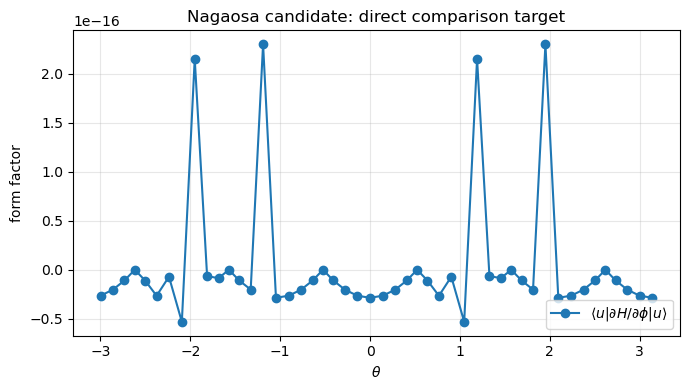

Nagaosa candidate summary:
min/max = -5.312939261812483e-17 2.3010216578190703e-16
mean/std = 2.9685693009064e-18 6.729312158432157e-17


In [17]:
# ============================================================
# Cell 2: rerun Q=0 tests for the three current classes
#   - real-space class pattern
#   - patch-space form factor
#   - angle profile
#   - harmonic weights
#   - overlap among the three current classes
#   - overlap vs Q=0 ph-real candidates (FM, PI)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

families = ["LC_Q0_NAGAOSA", "LC_Q0_FLOWA", "LC_Q0_FLOWB"]

# ------------------------------------------------------------
# Build candidates
# ------------------------------------------------------------
q0_currents = {}
for fam in families:
    q0_currents[fam] = build_q0_current_family(
        model=model_q0,
        patchset=patchset_q0,
        band_index=BAND_INDEX,
        family=fam,
    )

# flatten for testing
flat_current = []
for fam, cand_list in q0_currents.items():
    for idx, cand in enumerate(cand_list):
        flat_current.append({
            "family": fam,
            "name": cand.spec.name,
            "member_index": idx,
            "cand": cand,
            "vec": np.asarray(cand.vector_patch, dtype=complex),
        })

# ------------------------------------------------------------
# 1) visualize class pattern + form factor + angle profile + harmonic weights
# ------------------------------------------------------------
for item in flat_current:
    fam = item["family"]
    cand = item["cand"]
    idx = item["member_index"]

    ks = np.asarray(cand.patch_k, dtype=float)
    theta = np.arctan2(ks[:, 1], ks[:, 0])
    order = np.argsort(theta)
    th = theta[order]
    ff = np.real(np.asarray(cand.vector_patch))[order]

    df_sub, df_raw = harmonic_summary(cand, lmax=8)

    fig = plt.figure(figsize=(13, 10))

    ax1 = plt.subplot(2, 2, 1)
    draw_q0_current_class(ax1, fam, member_index=idx, title=f"{fam} : {cand.spec.name}")

    ax2 = plt.subplot(2, 2, 2)
    sc = ax2.scatter(
        ks[:, 0], ks[:, 1],
        c=np.real(cand.vector_patch),
        s=65,
        edgecolor="k",
    )
    for i, k in enumerate(ks):
        ax2.text(k[0], k[1], str(i), fontsize=7, ha="left", va="bottom")
    ax2.set_aspect("equal")
    ax2.set_title(f"Patch-space form factor: {cand.spec.name}")
    ax2.set_xlabel("$k_x$")
    ax2.set_ylabel("$k_y$")
    plt.colorbar(sc, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = plt.subplot(2, 2, 3)
    df_plot = df_sub[df_sub["l"] != "residual"].copy()
    ax3.bar(df_plot["l"].astype(int), df_plot["subspace_weight"].astype(float))
    ax3.set_xlabel("angular momentum l")
    ax3.set_ylabel("projected weight")
    ax3.set_title("Weight in harmonic subspaces")
    ax3.set_ylim(0, 1.0)
    ax3.grid(alpha=0.3, axis="y")

    ax4 = plt.subplot(2, 2, 4)
    ax4.plot(th, ff, "o-", label="patch form factor")
    ax4.set_xlabel(r"$\theta$")
    ax4.set_ylabel(r"$f(\theta)$")
    ax4.set_title("Patch-angle profile")
    ax4.grid(alpha=0.3)
    ax4.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n=== {cand.spec.name} ===")
    display(df_sub)
    display(df_raw.head(10))

# ------------------------------------------------------------
# 2) current-vs-current overlaps
# ------------------------------------------------------------
def abs_overlap(a, b):
    a = _normalize(a)
    b = _normalize(b)
    return float(abs(np.vdot(a, b)))

rows = []
for i, ai in enumerate(flat_current):
    for j, aj in enumerate(flat_current):
        rows.append({
            "left": ai["name"],
            "right": aj["name"],
            "abs_overlap": abs_overlap(ai["vec"], aj["vec"]),
        })
df_cc = pd.DataFrame(rows)
display(df_cc.pivot(index="left", columns="right", values="abs_overlap"))

# heatmap
names = [x["name"] for x in flat_current]
M = np.zeros((len(flat_current), len(flat_current)), dtype=float)
for i, ai in enumerate(flat_current):
    for j, aj in enumerate(flat_current):
        M[i, j] = abs_overlap(ai["vec"], aj["vec"])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(M, aspect="auto")
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=90)
ax.set_yticklabels(names)
ax.set_title("Q=0 current candidates: overlap matrix")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) current-vs-Q0 ph-real overlaps
# ------------------------------------------------------------
ph_real_q0 = cdr_ph.build_default_ph_real_candidates(
    model=model_q0,
    patchset=patchset_q0,
    band_index=BAND_INDEX,
    families=["FM_Q0", "PI_Q0_E2"],
    Q=np.zeros(2),
)

flat_real = []
for fam, cand_list in ph_real_q0.items():
    for cand in cand_list:
        flat_real.append({
            "family": fam,
            "name": cand.spec.name,
            "vec": np.asarray(cand.vector_patch, dtype=complex),
        })

rows = []
for ci in flat_current:
    for rr in flat_real:
        rows.append({
            "current": ci["name"],
            "real": rr["name"],
            "abs_overlap": abs_overlap(ci["vec"], rr["vec"]),
        })
df_cr = pd.DataFrame(rows)
display(df_cr.pivot(index="current", columns="real", values="abs_overlap"))

# ------------------------------------------------------------
# 4) direct comparison with your previous Nagaosa-style test
# ------------------------------------------------------------
if MODEL_KIND.lower() == "nagaosa":
    nagaosa = q0_currents["LC_Q0_NAGAOSA"][0]
    ks = np.asarray(nagaosa.patch_k, dtype=float)
    theta = np.arctan2(ks[:, 1], ks[:, 0])
    order = np.argsort(theta)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(theta[order], np.real(nagaosa.vector_patch)[order], "o-", label=r'$\langle u | \partial H/\partial \phi | u \rangle$')
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel("form factor")
    ax.set_title("Nagaosa candidate: direct comparison target")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Nagaosa candidate summary:")
    print("min/max =", float(np.min(np.real(nagaosa.vector_patch))), float(np.max(np.real(nagaosa.vector_patch))))
    print("mean/std =", float(np.mean(np.real(nagaosa.vector_patch))), float(np.std(np.real(nagaosa.vector_patch))))

Candidate labels:
  0: LC_Q0_NAGAOSA
  1: LC_Q0_FLOWA
  2: LC_Q0_FLOWB_0
  3: LC_Q0_FLOWB_1
  4: LC_Q0_FLOWB_2

Matrix shape = (48, 5)

Absolute-overlap Gram matrix:


,LC_Q0_NAGAOSA,LC_Q0_FLOWA,LC_Q0_FLOWB_0,LC_Q0_FLOWB_1,LC_Q0_FLOWB_2
LC_Q0_NAGAOSA,1.000000,0.836985,0.972975,0.945373,0.971646
LC_Q0_FLOWA,0.836985,1.000000,0.893788,0.613327,0.913892
LC_Q0_FLOWB_0,0.972975,0.893788,1.000000,0.870888,0.945600
LC_Q0_FLOWB_1,0.945373,0.613327,0.870888,1.000000,0.860592
LC_Q0_FLOWB_2,0.971646,0.913892,0.945600,0.860592,1.000000


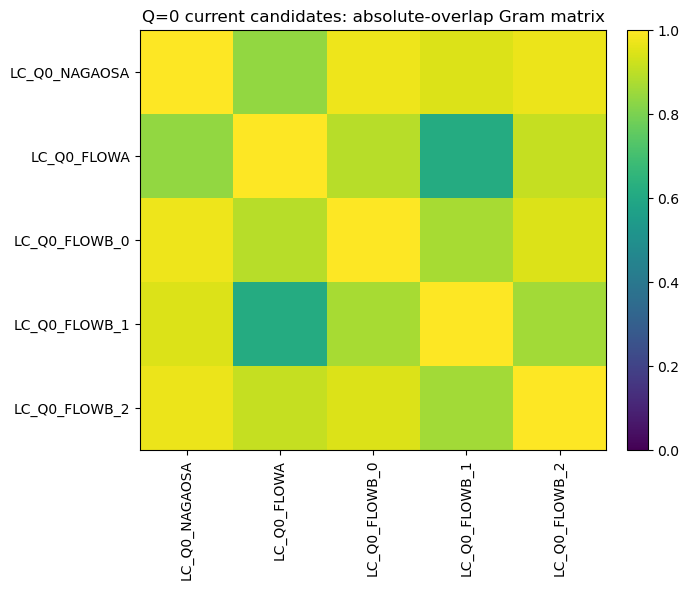


Singular values:


,index,singular_value,relative_to_max
0,0,2.130668e+00,1.000000e+00
1,1,6.371401e-01,2.990331e-01
2,2,2.327165e-01,1.092223e-01
3,3,1.230696e-02,5.776108e-03
4,4,2.015959e-16,9.461629e-17


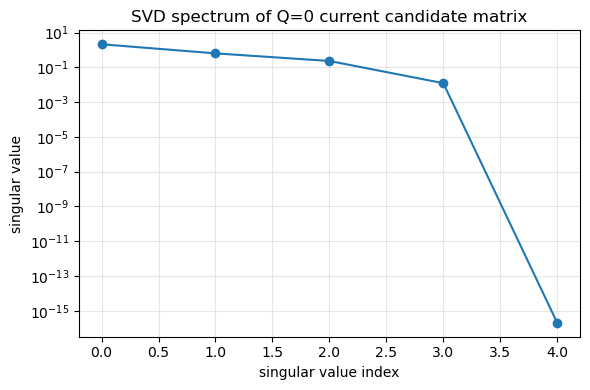


Estimated numerical rank:


,threshold,rank_using_relative_threshold,rank_using_absolute_threshold
0,1.000000e-01,3,3
1,5.000000e-02,3,3
2,1.000000e-02,3,4
3,1.000000e-03,4,4
4,1.000000e-04,4,4
5,1.000000e-06,4,4
6,1.000000e-08,4,4
7,1.000000e-10,4,4



Gram-Schmidt basis labels (tol=1e-2):
['LC_Q0_NAGAOSA', 'LC_Q0_FLOWA', 'LC_Q0_FLOWB_0', 'LC_Q0_FLOWB_1']
Gram-Schmidt rank = 4


,candidate,projected_weight_on_existing_basis,residual_norm_before_norm,kept_as_new_basis_vector,max_overlap_with_existing_basis
0,LC_Q0_NAGAOSA,0.000000,1.000000e+00,True,0.000000
1,LC_Q0_FLOWA,0.700544,5.472256e-01,True,0.836985
2,LC_Q0_FLOWB_0,0.967745,1.795967e-01,True,0.972975
3,LC_Q0_FLOWB_1,0.999554,2.112263e-02,True,0.945373
4,LC_Q0_FLOWB_2,1.000000,8.878922e-17,False,0.971646


GS tol=    0.1 -> rank 3 ; basis ['LC_Q0_NAGAOSA', 'LC_Q0_FLOWA', 'LC_Q0_FLOWB_0']
GS tol=   0.05 -> rank 3 ; basis ['LC_Q0_NAGAOSA', 'LC_Q0_FLOWA', 'LC_Q0_FLOWB_0']
GS tol=   0.01 -> rank 4 ; basis ['LC_Q0_NAGAOSA', 'LC_Q0_FLOWA', 'LC_Q0_FLOWB_0', 'LC_Q0_FLOWB_1']
GS tol=  0.001 -> rank 4 ; basis ['LC_Q0_NAGAOSA', 'LC_Q0_FLOWA', 'LC_Q0_FLOWB_0', 'LC_Q0_FLOWB_1']
GS tol= 0.0001 -> rank 4 ; basis ['LC_Q0_NAGAOSA', 'LC_Q0_FLOWA', 'LC_Q0_FLOWB_0', 'LC_Q0_FLOWB_1']

Top principal-direction compositions (by |coefficient|):

PC 0, singular value = 2.13067


...


PC 1, singular value = 0.63714


,pc,candidate,coefficient_real,coefficient_imag,coefficient_abs
0,1,LC_Q0_FLOWA,-0.702814,0.0,0.702814
1,1,LC_Q0_FLOWB_1,-0.677243,0.0,0.677243
2,1,LC_Q0_NAGAOSA,-0.179533,0.0,0.179533
3,1,LC_Q0_FLOWB_2,-0.111959,0.0,0.111959
4,1,LC_Q0_FLOWB_0,-0.051255,0.0,0.051255



PC 2, singular value = 0.232717


,pc,candidate,coefficient_real,coefficient_imag,coefficient_abs
0,2,LC_Q0_FLOWB_0,0.751405,0.0,0.751405
1,2,LC_Q0_FLOWB_2,-0.656181,0.0,0.656181
2,2,LC_Q0_FLOWB_1,0.064418,0.0,0.064418
3,2,LC_Q0_NAGAOSA,0.019225,0.0,0.019225
4,2,LC_Q0_FLOWA,-0.017253,0.0,0.017253



Default reduced current-subspace rank (relative threshold 1e-2): 3
You can now use `current_subspace_basis` as an orthonormal basis for the reduced Q=0 current sector.


In [7]:
# ============================================================
# Test cell: rank / SVD / Gram-Schmidt analysis of Q=0 current candidates
#   Goal:
#     1) estimate numerical rank
#     2) inspect singular values
#     3) build an orthonormal basis for the current subspace
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Expect these from previous cells:
#   flat_current : list of dicts, each with keys
#       "name", "vec", ...
# If not present, raise a clean error.
# ------------------------------------------------------------
if "flat_current" not in globals():
    raise RuntimeError("flat_current not found. Please run the previous Q=0 current builder/test cells first.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def normalize(v, tol=1e-30):
    v = np.asarray(v, dtype=complex).reshape(-1)
    n = np.linalg.norm(v)
    if n <= tol:
        return np.zeros_like(v)
    return v / n

def gram_schmidt(vectors, labels=None, tol=1e-10):
    """
    Classical Gram-Schmidt with overlap diagnostics.
    Returns:
      basis_vecs, basis_labels, residual_report
    """
    basis_vecs = []
    basis_labels = []
    residual_rows = []

    if labels is None:
        labels = [f"v{i}" for i in range(len(vectors))]

    for lab, v in zip(labels, vectors):
        v0 = normalize(v)
        w = v0.copy()

        proj_norm_sq = 0.0
        overlaps = {}
        for b_lab, b in zip(basis_labels, basis_vecs):
            coeff = np.vdot(b, w)
            overlaps[b_lab] = abs(coeff)
            proj_norm_sq += abs(coeff)**2
            w = w - coeff * b

        res_norm = np.linalg.norm(w)
        kept = res_norm > tol
        if kept:
            w = w / res_norm
            basis_vecs.append(w)
            basis_labels.append(lab)

        residual_rows.append({
            "candidate": lab,
            "projected_weight_on_existing_basis": float(proj_norm_sq),
            "residual_norm_before_norm": float(res_norm),
            "kept_as_new_basis_vector": bool(kept),
            "max_overlap_with_existing_basis": float(max(overlaps.values()) if overlaps else 0.0),
        })

    return basis_vecs, basis_labels, pd.DataFrame(residual_rows)

def abs_overlap(a, b):
    a = normalize(a)
    b = normalize(b)
    return float(abs(np.vdot(a, b)))

# ------------------------------------------------------------
# Build candidate matrix
#   columns = normalized candidate vectors
# ------------------------------------------------------------
labels = [x["name"] for x in flat_current]
vecs   = [normalize(x["vec"]) for x in flat_current]

# matrix shape: (Npatch, Ncand)
X = np.column_stack(vecs)

print("Candidate labels:")
for i, lab in enumerate(labels):
    print(f"  {i}: {lab}")

print("\nMatrix shape =", X.shape)

# ------------------------------------------------------------
# 1) Gram matrix
# ------------------------------------------------------------
G = np.abs(X.conjugate().T @ X)

df_gram = pd.DataFrame(G, index=labels, columns=labels)
print("\nAbsolute-overlap Gram matrix:")
display(df_gram)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(G, aspect="auto", vmin=0.0, vmax=1.0)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)
ax.set_title("Q=0 current candidates: absolute-overlap Gram matrix")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) SVD / singular values
# ------------------------------------------------------------
U, S, Vh = np.linalg.svd(X, full_matrices=False)

df_sv = pd.DataFrame({
    "index": np.arange(len(S)),
    "singular_value": S,
    "relative_to_max": S / max(S[0], 1e-30),
})
print("\nSingular values:")
display(df_sv)

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(np.arange(len(S)), S, "o-")
ax.set_xlabel("singular value index")
ax.set_ylabel("singular value")
ax.set_title("SVD spectrum of Q=0 current candidate matrix")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) Numerical rank under several thresholds
# ------------------------------------------------------------
thresholds = [1e-1, 5e-2, 1e-2, 1e-3, 1e-4, 1e-6, 1e-8, 1e-10]
rows = []
s0 = max(S[0], 1e-30)
for thr in thresholds:
    rank_rel = int(np.sum(S / s0 > thr))
    rank_abs = int(np.sum(S > thr))
    rows.append({
        "threshold": thr,
        "rank_using_relative_threshold": rank_rel,
        "rank_using_absolute_threshold": rank_abs,
    })

df_rank = pd.DataFrame(rows)
print("\nEstimated numerical rank:")
display(df_rank)

# ------------------------------------------------------------
# 4) Gram-Schmidt rank test
# ------------------------------------------------------------
basis_vecs, basis_labels, df_gs = gram_schmidt(vecs, labels=labels, tol=1e-2)

print("\nGram-Schmidt basis labels (tol=1e-2):")
print(basis_labels)
print(f"Gram-Schmidt rank = {len(basis_labels)}")

display(df_gs)

# also show stricter tolerances
for gs_tol in [1e-1, 5e-2, 1e-2, 1e-3, 1e-4]:
    bvecs_tmp, blabs_tmp, _ = gram_schmidt(vecs, labels=labels, tol=gs_tol)
    print(f"GS tol={gs_tol:>7g} -> rank {len(blabs_tmp)} ; basis {blabs_tmp}")

# ------------------------------------------------------------
# 5) Inspect principal directions
#    Each right singular vector tells you how each candidate
#    contributes to one independent current-subspace direction.
# ------------------------------------------------------------
# Vh rows correspond to principal directions in candidate space
principal_rows = []
for pc in range(len(S)):
    for j, lab in enumerate(labels):
        principal_rows.append({
            "pc": pc,
            "candidate": lab,
            "coefficient_real": float(np.real(Vh[pc, j])),
            "coefficient_imag": float(np.imag(Vh[pc, j])),
            "coefficient_abs": float(abs(Vh[pc, j])),
        })

df_pc = pd.DataFrame(principal_rows)

print("\nTop principal-direction compositions (by |coefficient|):")
for pc in range(min(3, len(S))):
    print(f"\nPC {pc}, singular value = {S[pc]:.6g}")
    display(
        df_pc[df_pc["pc"] == pc]
        .sort_values("coefficient_abs", ascending=False)
        .reset_index(drop=True)
        .head(len(labels))
    )

# ------------------------------------------------------------
# 6) Optional: construct reduced current subspace basis vectors
# ------------------------------------------------------------
# Choose rank from relative threshold = 1e-2 by default
rank_default = int(np.sum(S / s0 > 1e-2))
current_subspace_basis = [U[:, i] for i in range(rank_default)]

print(f"\nDefault reduced current-subspace rank (relative threshold 1e-2): {rank_default}")
print("You can now use `current_subspace_basis` as an orthonormal basis for the reduced Q=0 current sector.")

Chosen 3 current patterns:
  0: LC_Q0_NAGAOSA
  1: LC_Q0_FLOWA
  2: LC_Q0_FLOWB_0

Absolute-overlap Gram matrix:


,LC_Q0_NAGAOSA,LC_Q0_FLOWA,LC_Q0_FLOWB_0
LC_Q0_NAGAOSA,1.000000,0.836985,0.972975
LC_Q0_FLOWA,0.836985,1.000000,0.893788
LC_Q0_FLOWB_0,0.972975,0.893788,1.000000


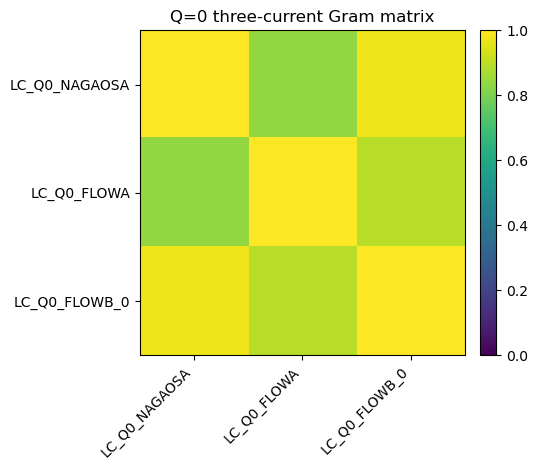


Pairwise angles:


,left,right,abs_overlap,angle_deg
0,LC_Q0_NAGAOSA,LC_Q0_FLOWB_0,0.972975,13.350710
1,LC_Q0_FLOWA,LC_Q0_FLOWB_0,0.893788,26.646768
2,LC_Q0_NAGAOSA,LC_Q0_FLOWA,0.836985,33.176886



Singular values:


,index,singular_value,relative_to_max
0,0,1.674413,1.000000
1,1,0.420549,0.251162
2,2,0.139568,0.083353


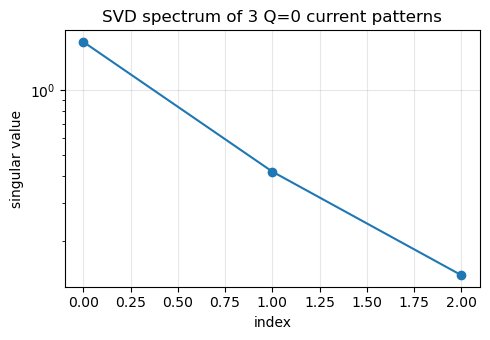


Estimated numerical rank:


,threshold,rank_relative,rank_absolute
0,1.000000e-01,2,3
1,5.000000e-02,3,3
2,1.000000e-02,3,3
3,1.000000e-03,3,3
4,1.000000e-04,3,3
5,1.000000e-06,3,3
6,1.000000e-08,3,3



PC 0, singular value = 1.67441


,pc,candidate,coeff_real,coeff_imag,coeff_abs
0,0,LC_Q0_FLOWB_0,0.590790,0.0,0.590790
1,0,LC_Q0_NAGAOSA,-0.579301,0.0,0.579301
2,0,LC_Q0_FLOWA,0.561585,0.0,0.561585



PC 1, singular value = 0.420549


,pc,candidate,coeff_real,coeff_imag,coeff_abs
0,1,LC_Q0_FLOWA,-0.806834,0.0,0.806834
1,1,LC_Q0_NAGAOSA,-0.541678,0.0,0.541678
2,1,LC_Q0_FLOWB_0,0.235805,0.0,0.235805



PC 2, singular value = 0.139568


,pc,candidate,coeff_real,coeff_imag,coeff_abs
0,2,LC_Q0_FLOWB_0,0.771598,0.0,0.771598
1,2,LC_Q0_NAGAOSA,0.609094,0.0,0.609094
2,2,LC_Q0_FLOWA,-0.183415,0.0,0.183415



================ Verdict ================
rank @ relative threshold 1e-1 : 2
rank @ relative threshold 1e-2 : 3
Verdict: one of the 3 patterns is already strongly collapsed into the span of the other two.


In [8]:
# ============================================================
# Test cell: Q=0 only, keep exactly THREE current patterns
# Goal:
#   Determine whether the 3 physical 1x1 current patterns are
#   distinguishable in the band-projected patch space.
#
# Output:
#   1) Gram matrix
#   2) singular values
#   3) numerical rank
#   4) pairwise angles
#   5) simple verdict
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# REQUIREMENT:
# You should already have from the previous notebook-local cells:
#   - build_q0_current_family(...)
#   - model_q0
#   - patchset_q0
#   - BAND_INDEX
#
# IMPORTANT:
# Here we keep EXACTLY 3 current patterns.
#
# By default I use:
#   1. LC_Q0_NAGAOSA
#   2. LC_Q0_FLOWA
#   3. one representative of FLOWB family
#
# If later you redefine the "official" three 1x1 classes differently,
# just change THREE_FAMILIES below.
# ------------------------------------------------------------

THREE_FAMILIES = [
    ("LC_Q0_NAGAOSA", 0),   # family, member index
    ("LC_Q0_FLOWA",   0),
    ("LC_Q0_FLOWB",   0),   # choose one representative from FLOWB family
]

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def normalize(v, tol=1e-30):
    v = np.asarray(v, dtype=complex).reshape(-1)
    n = np.linalg.norm(v)
    if n <= tol:
        return np.zeros_like(v)
    return v / n

def abs_overlap(a, b):
    a = normalize(a)
    b = normalize(b)
    return float(abs(np.vdot(a, b)))

def angle_deg(a, b):
    ov = np.clip(abs_overlap(a, b), 0.0, 1.0)
    return float(np.degrees(np.arccos(ov)))

# ------------------------------------------------------------
# build exactly 3 candidates
# ------------------------------------------------------------
three_candidates = []
for fam, member_idx in THREE_FAMILIES:
    cand_list = build_q0_current_family(
        model=model_q0,
        patchset=patchset_q0,
        band_index=BAND_INDEX,
        family=fam,
    )
    if member_idx >= len(cand_list):
        raise IndexError(f"{fam} has only {len(cand_list)} members, requested member {member_idx}.")
    cand = cand_list[member_idx]
    three_candidates.append({
        "family": fam,
        "name": cand.spec.name,
        "vec": np.asarray(cand.vector_patch, dtype=complex),
        "cand": cand,
    })

labels = [x["name"] for x in three_candidates]
vecs   = [normalize(x["vec"]) for x in three_candidates]

print("Chosen 3 current patterns:")
for i, lab in enumerate(labels):
    print(f"  {i}: {lab}")

# ------------------------------------------------------------
# 1) Gram matrix
# ------------------------------------------------------------
G = np.zeros((3, 3), dtype=float)
for i in range(3):
    for j in range(3):
        G[i, j] = abs_overlap(vecs[i], vecs[j])

df_gram = pd.DataFrame(G, index=labels, columns=labels)
print("\nAbsolute-overlap Gram matrix:")
display(df_gram)

fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(G, vmin=0.0, vmax=1.0)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_title("Q=0 three-current Gram matrix")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) Angles
# ------------------------------------------------------------
rows = []
for i in range(3):
    for j in range(i+1, 3):
        rows.append({
            "left": labels[i],
            "right": labels[j],
            "abs_overlap": G[i, j],
            "angle_deg": angle_deg(vecs[i], vecs[j]),
        })
df_angles = pd.DataFrame(rows)
print("\nPairwise angles:")
display(df_angles.sort_values("abs_overlap", ascending=False).reset_index(drop=True))

# ------------------------------------------------------------
# 3) SVD / rank
# ------------------------------------------------------------
X = np.column_stack(vecs)   # shape (Npatch, 3)
U, S, Vh = np.linalg.svd(X, full_matrices=False)

df_sv = pd.DataFrame({
    "index": np.arange(len(S)),
    "singular_value": S,
    "relative_to_max": S / max(S[0], 1e-30),
})
print("\nSingular values:")
display(df_sv)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.semilogy(np.arange(len(S)), S, "o-")
ax.set_xlabel("index")
ax.set_ylabel("singular value")
ax.set_title("SVD spectrum of 3 Q=0 current patterns")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# rank table
thresholds = [1e-1, 5e-2, 1e-2, 1e-3, 1e-4, 1e-6, 1e-8]
rows = []
s0 = max(S[0], 1e-30)
for thr in thresholds:
    rows.append({
        "threshold": thr,
        "rank_relative": int(np.sum(S / s0 > thr)),
        "rank_absolute": int(np.sum(S > thr)),
    })
df_rank = pd.DataFrame(rows)
print("\nEstimated numerical rank:")
display(df_rank)

# ------------------------------------------------------------
# 4) principal-direction composition
# ------------------------------------------------------------
rows = []
for pc in range(len(S)):
    for j, lab in enumerate(labels):
        rows.append({
            "pc": pc,
            "candidate": lab,
            "coeff_real": float(np.real(Vh[pc, j])),
            "coeff_imag": float(np.imag(Vh[pc, j])),
            "coeff_abs": float(abs(Vh[pc, j])),
        })
df_pc = pd.DataFrame(rows)

for pc in range(len(S)):
    print(f"\nPC {pc}, singular value = {S[pc]:.6g}")
    display(
        df_pc[df_pc["pc"] == pc]
        .sort_values("coeff_abs", ascending=False)
        .reset_index(drop=True)
    )

# ------------------------------------------------------------
# 5) simple verdict
# ------------------------------------------------------------
rank_1e2 = int(np.sum(S / s0 > 1e-2))
rank_1e1 = int(np.sum(S / s0 > 1e-1))

print("\n================ Verdict ================")
print(f"rank @ relative threshold 1e-1 : {rank_1e1}")
print(f"rank @ relative threshold 1e-2 : {rank_1e2}")

if rank_1e1 == 3:
    print("Verdict: the 3 Q=0 current patterns are clearly linearly independent in patch space.")
elif rank_1e1 == 2:
    print("Verdict: one of the 3 patterns is already strongly collapsed into the span of the other two.")
elif rank_1e1 == 1:
    print("Verdict: the 3 patterns are effectively the same direction in patch space.")
else:
    print("Verdict: borderline / threshold-sensitive. Check singular values carefully.")

if np.max(df_angles["abs_overlap"]) > 0.95:
    print("Warning: at least one pair is extremely close, so even if rank=3, numerical distinguishability may still be weak.")
elif np.max(df_angles["abs_overlap"]) > 0.85:
    print("Warning: some pairs are strongly aligned; distinction exists but is not very clean.")
else:
    print("Good: pairwise overlaps are moderate enough that the 3-pattern distinction is relatively clean.")

Using exact/microscopic Q=0 helper for NAGAOSA/FLOWA.


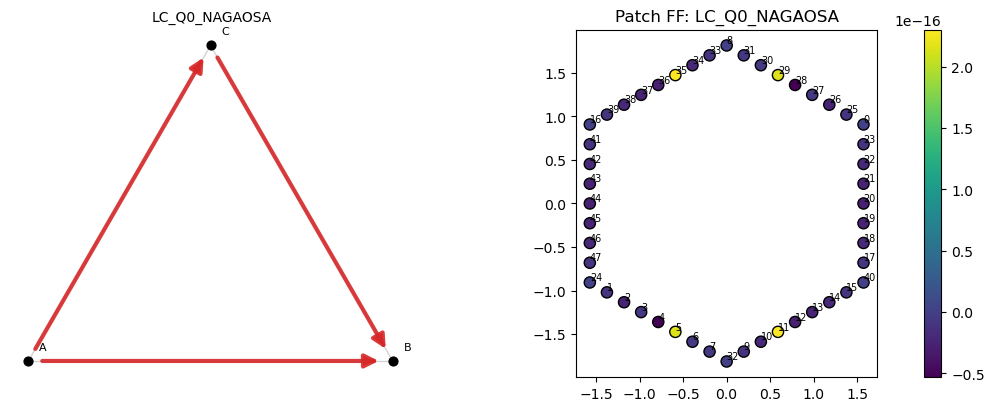

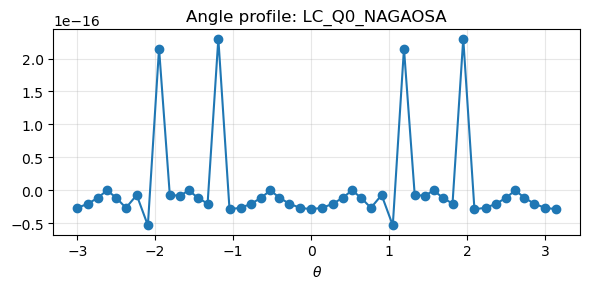

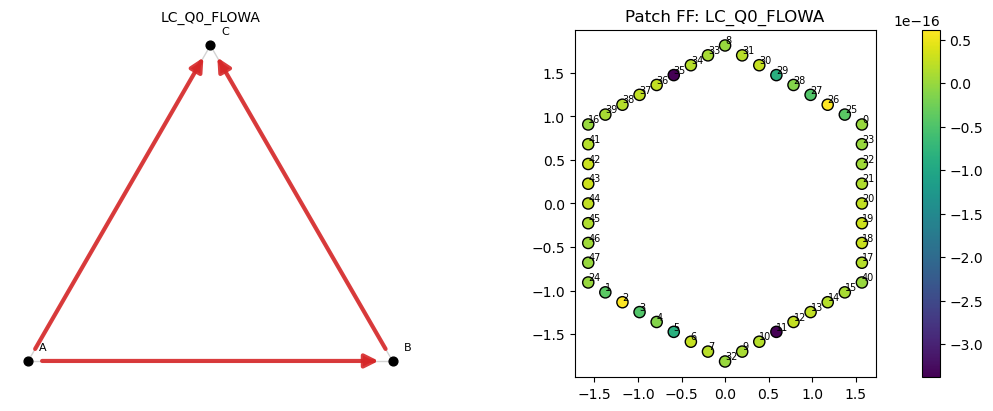

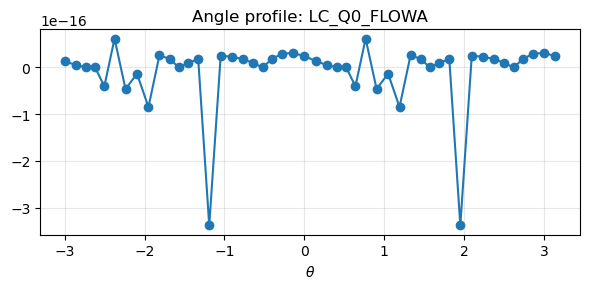


===== Q=0 current Gram matrix =====


,LC_Q0_NAGAOSA,LC_Q0_FLOWA
LC_Q0_NAGAOSA,1.000000,0.836985
LC_Q0_FLOWA,0.836985,1.000000


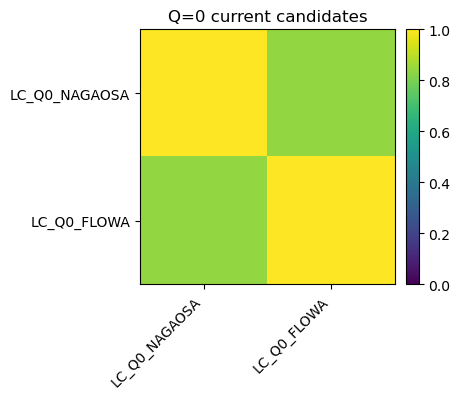


===== SVD report: Q=0 current sector =====


,index,singular_value,relative_to_max
0,0,1.355354,1.000000
1,1,0.403751,0.297893


,threshold,rank_relative,rank_absolute
0,1.000000e-01,2,2
1,5.000000e-02,2,2
2,1.000000e-02,2,2
3,1.000000e-03,2,2
4,1.000000e-04,2,2
5,1.000000e-06,2,2
6,1.000000e-08,2,2


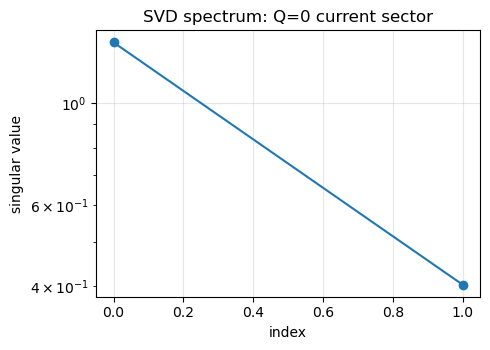


PC 0, singular value = 1.35535


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_Q0_FLOWA,0.707107,0.0,0.707107
1,LC_Q0_NAGAOSA,-0.707107,0.0,0.707107



PC 1, singular value = 0.403751


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_Q0_NAGAOSA,0.707107,0.0,0.707107
1,LC_Q0_FLOWA,0.707107,0.0,0.707107



===== Q=0 current vs Q0 ph-real overlaps =====


,FM_Q0,PI_Q0_dx2y2,PI_Q0_dxy
current,,,
LC_Q0_NAGAOSA,0.044071,0.304733,0.006547
LC_Q0_FLOWA,0.106393,0.230930,0.032415


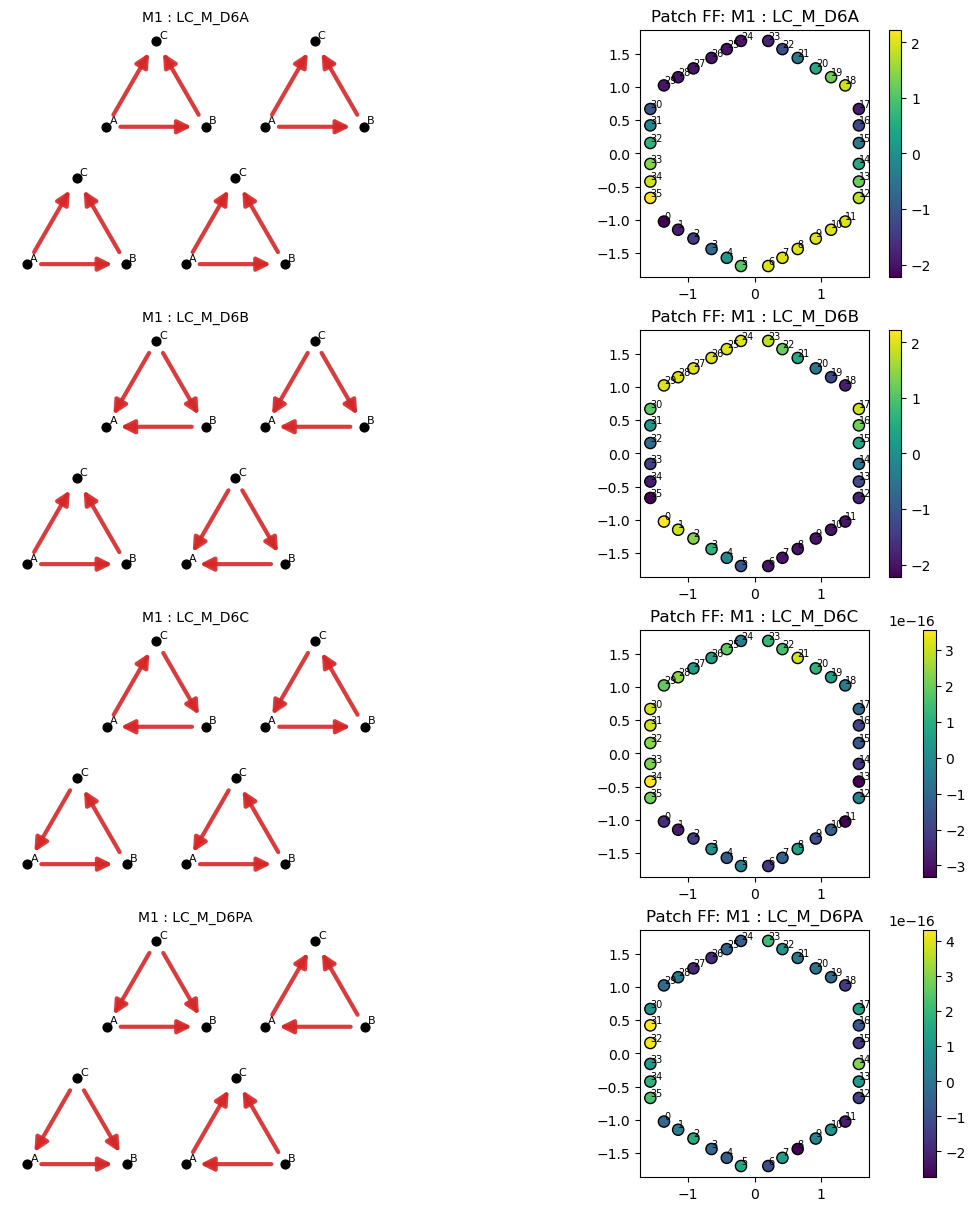

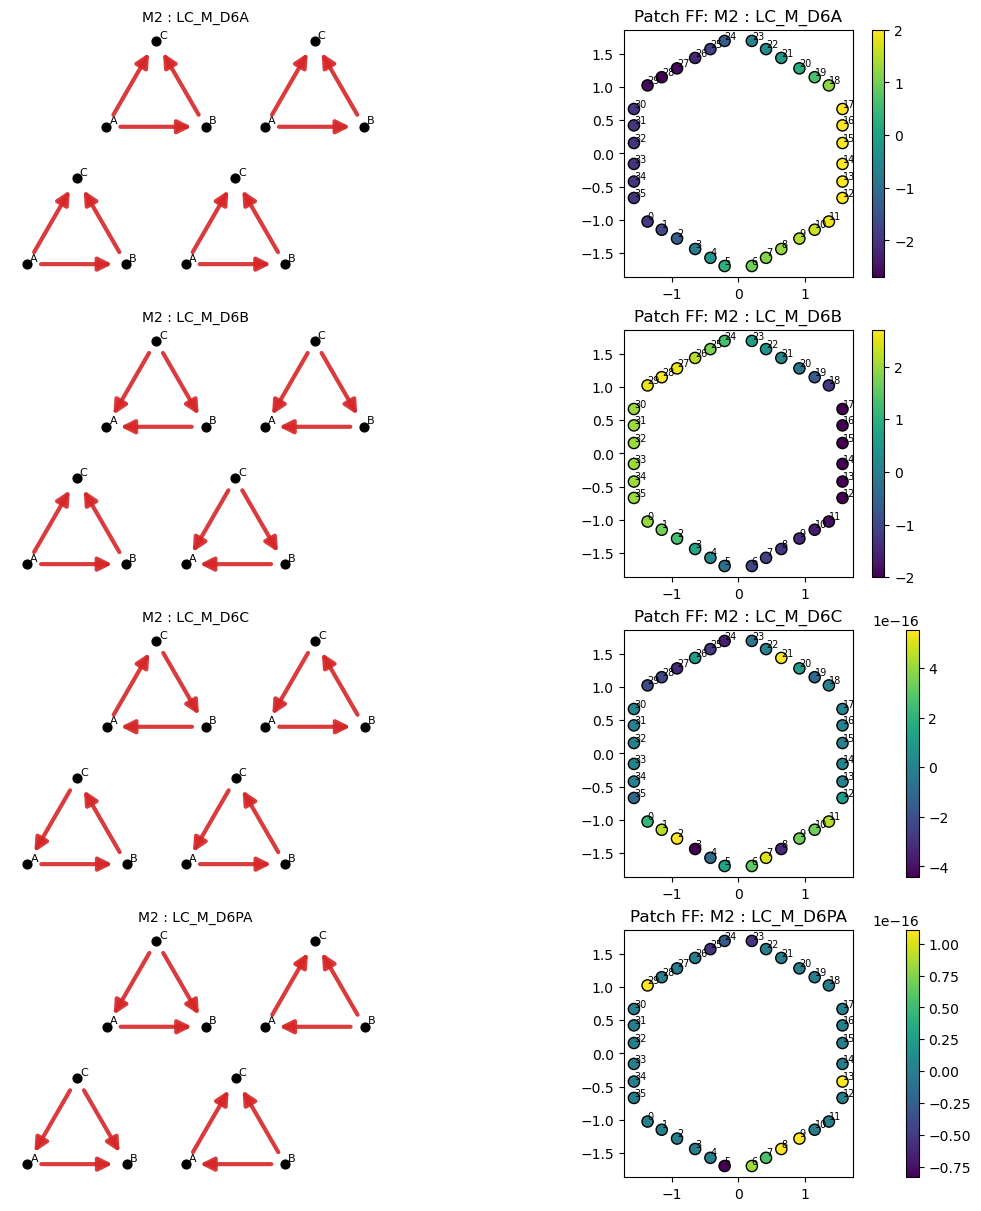

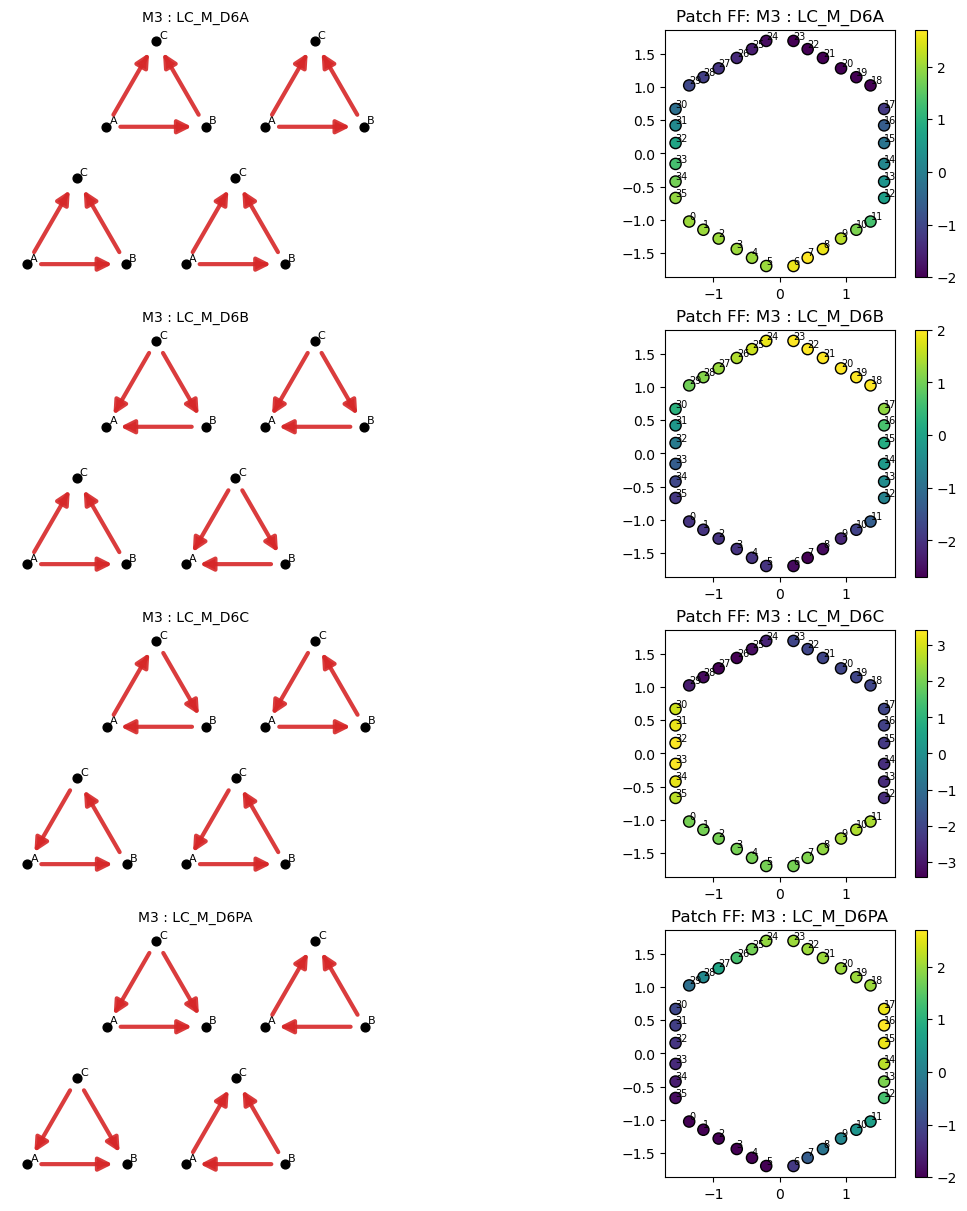


===== M1 current Gram matrix =====


,LC_M_D6A,LC_M_D6B,LC_M_D6C,LC_M_D6PA
LC_M_D6A,1.000000,1.000000,0.104011,0.535950
LC_M_D6B,1.000000,1.000000,0.104011,0.535950
LC_M_D6C,0.104011,0.104011,1.000000,0.713685
LC_M_D6PA,0.535950,0.535950,0.713685,1.000000


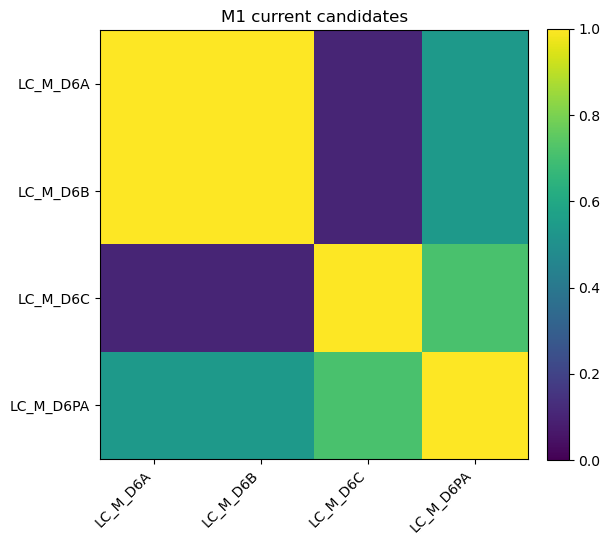


===== SVD report: M1 current sector =====


,index,singular_value,relative_to_max
0,0,1.601163e+00,1.000000e+00
1,1,1.126481e+00,7.035394e-01
2,2,4.090427e-01,2.554659e-01
3,3,2.367271e-16,1.478470e-16


,threshold,rank_relative,rank_absolute
0,1.000000e-01,3,3
1,5.000000e-02,3,3
2,1.000000e-02,3,3
3,1.000000e-03,3,3
4,1.000000e-04,3,3
5,1.000000e-06,3,3
6,1.000000e-08,3,3


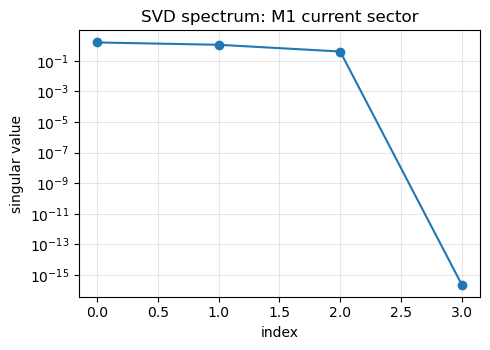


PC 0, singular value = 1.60116


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6B,-3.949429e-01,-3.949429e-01,0.558534
1,LC_M_D6A,5.585335e-01,0.000000e+00,0.558534
2,LC_M_D6PA,-2.111426e-17,5.264307e-01,0.526431
3,LC_M_D6C,-3.145652e-01,-2.786135e-18,0.314565



PC 1, singular value = 1.12648


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6C,7.352597e-01,1.422630e-17,0.735260
1,LC_M_D6B,-2.767567e-01,-2.767567e-01,0.391393
2,LC_M_D6A,3.913931e-01,0.000000e+00,0.391393
3,LC_M_D6PA,3.514708e-17,-3.911726e-01,0.391173



PC 2, singular value = 0.409043


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6PA,1.462806e-16,-7.548872e-01,0.754887
1,LC_M_D6C,-6.003682e-01,-8.654222e-17,0.600368
2,LC_M_D6A,1.866861e-01,0.000000e+00,0.186686
3,LC_M_D6B,-1.320070e-01,-1.320070e-01,0.186686



PC 3, singular value = 2.36727e-16


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6B,5.000000e-01,5.000000e-01,7.071068e-01
1,LC_M_D6A,7.071068e-01,0.000000e+00,7.071068e-01
2,LC_M_D6C,1.020329e-16,1.703509e-17,1.034452e-16
3,LC_M_D6PA,-4.657709e-17,2.172249e-17,5.139350e-17



===== M2 current Gram matrix =====


,LC_M_D6A,LC_M_D6B,LC_M_D6C,LC_M_D6PA
LC_M_D6A,1.000000,1.000000,0.795118,0.192835
LC_M_D6B,1.000000,1.000000,0.795118,0.192835
LC_M_D6C,0.795118,0.795118,1.000000,0.361071
LC_M_D6PA,0.192835,0.192835,0.361071,1.000000


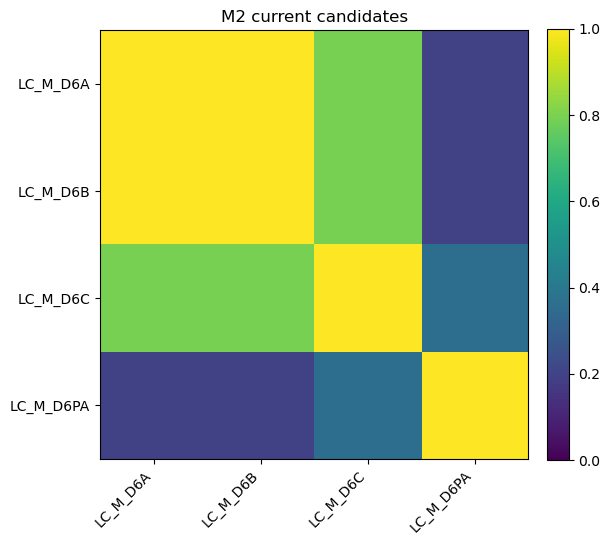


===== SVD report: M2 current sector =====


,index,singular_value,relative_to_max
0,0,1.682264e+00,1.000000e+00
1,1,9.669233e-01,5.747748e-01
2,2,4.848149e-01,2.881919e-01
3,3,2.618877e-16,1.556757e-16


,threshold,rank_relative,rank_absolute
0,1.000000e-01,3,3
1,5.000000e-02,3,3
2,1.000000e-02,3,3
3,1.000000e-03,3,3
4,1.000000e-04,3,3
5,1.000000e-06,3,3
6,1.000000e-08,3,3


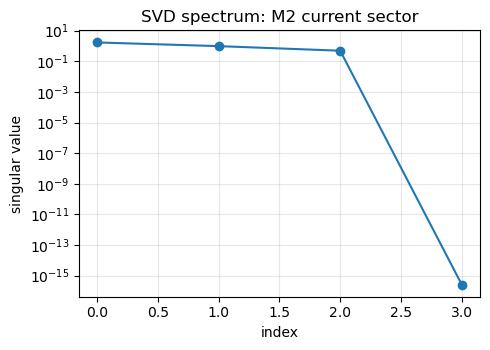


PC 0, singular value = 1.68226


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6A,0.572055,0.000000,0.572055
1,LC_M_D6B,-0.404504,-0.404504,0.572055
2,LC_M_D6C,0.383243,-0.383243,0.541988
3,LC_M_D6PA,0.160864,0.160864,0.227496



PC 1, singular value = 0.966923


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6PA,-0.671218,-0.671218,0.949246
1,LC_M_D6A,0.218062,0.000000,0.218062
2,LC_M_D6B,-0.154193,-0.154193,0.218062
3,LC_M_D6C,-0.043755,0.043755,0.061879



PC 2, singular value = 0.484815


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6C,-0.592630,0.592630,0.838105
1,LC_M_D6A,0.353838,0.000000,0.353838
2,LC_M_D6B,-0.250201,-0.250201,0.353838
3,LC_M_D6PA,0.153586,0.153586,0.217203



PC 3, singular value = 2.61888e-16


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6B,-5.000000e-01,-5.000000e-01,7.071068e-01
1,LC_M_D6A,-7.071068e-01,0.000000e+00,7.071068e-01
2,LC_M_D6C,2.383136e-17,1.041652e-16,1.068566e-16
3,LC_M_D6PA,2.987252e-17,-3.453020e-17,4.565854e-17



===== M3 current Gram matrix =====


,LC_M_D6A,LC_M_D6B,LC_M_D6C,LC_M_D6PA
LC_M_D6A,1.000000,1.000000,0.795118,0.717170
LC_M_D6B,1.000000,1.000000,0.795118,0.717170
LC_M_D6C,0.795118,0.795118,1.000000,0.795118
LC_M_D6PA,0.717170,0.717170,0.795118,1.000000


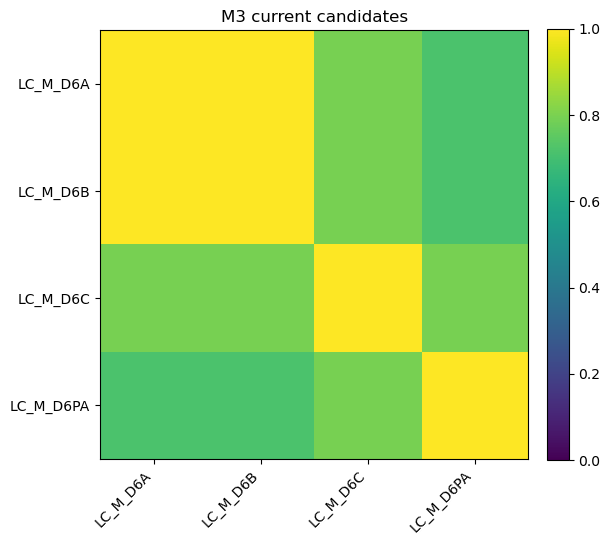


===== SVD report: M3 current sector =====


,index,singular_value,relative_to_max
0,0,1.847789e+00,1.000000e+00
1,1,6.296866e-01,3.407784e-01
2,2,4.349377e-01,2.353828e-01
3,3,1.705995e-16,9.232631e-17


,threshold,rank_relative,rank_absolute
0,1.000000e-01,3,3
1,5.000000e-02,3,3
2,1.000000e-02,3,3
3,1.000000e-03,3,3
4,1.000000e-04,3,3
5,1.000000e-06,3,3
6,1.000000e-08,3,3


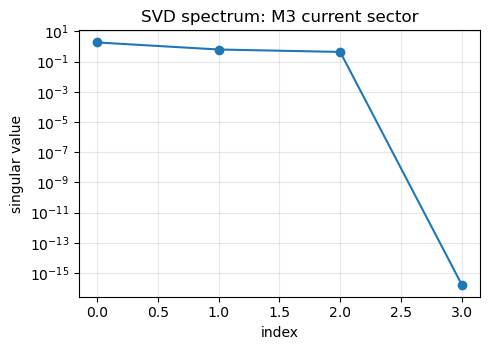


PC 0, singular value = 1.84779


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6B,3.653541e-01,0.365354,0.516689
1,LC_M_D6A,-5.166888e-01,0.000000,0.516689
2,LC_M_D6C,-3.501030e-01,-0.350103,0.495120
3,LC_M_D6PA,2.090384e-17,0.470023,0.470023



PC 1, singular value = 0.629687


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6PA,-1.464613e-17,-0.688645,0.688645
1,LC_M_D6A,-4.627816e-01,0.000000,0.462782
2,LC_M_D6B,3.272360e-01,0.327236,0.462782
3,LC_M_D6C,2.207200e-01,0.220720,0.312145



PC 2, singular value = 0.434938


...


PC 3, singular value = 1.706e-16


,candidate,coeff_real,coeff_imag,coeff_abs
0,LC_M_D6A,-7.071068e-01,0.000000e+00,7.071068e-01
1,LC_M_D6B,-5.000000e-01,-5.000000e-01,7.071068e-01
2,LC_M_D6C,-1.139626e-16,1.541734e-18,1.139731e-16
3,LC_M_D6PA,-9.009551e-17,5.764245e-17,1.069573e-16


Q=M real-overlap tests skipped: ValueError('matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 6 is different from 3)')

===== Cross-M consistency of 2×2 current classes =====


,family,block_a,block_b,abs_overlap,angle_deg
0,LC_M_D6A,M1,M2,0.490958,60.596416
1,LC_M_D6A,M1,M3,0.490958,60.596416
2,LC_M_D6A,M2,M3,0.087696,84.968938
3,LC_M_D6B,M1,M2,0.490958,60.596416
4,LC_M_D6B,M1,M3,0.490958,60.596416
5,LC_M_D6B,M2,M3,0.087696,84.968938
6,LC_M_D6C,M1,M2,0.277096,73.913021
7,LC_M_D6C,M1,M3,0.002913,89.833119
8,LC_M_D6C,M2,M3,0.185072,79.334695
9,LC_M_D6PA,M1,M2,0.319765,71.351256



DONE. This first-pass cell gives you:
  - Q=0: Nagaosa + Flow-a
  - Q=M: D6a, D6b, D6c, D'6a high-symmetry proxies
  - visualization + Gram + SVD/rank + overlap vs ph-real

If the Q=M sector behaves cleanly enough, the next step is to replace the proxy
definitions by exact bond-by-bond Fig.6 reconstructions before writing the python file.


In [32]:
# ============================================================
# ONE-CELL TEST:
#   New ph-imaginary current candidate set
#
#   Q=0:
#       LC_Q0_NAGAOSA
#       LC_Q0_FLOWA
#
#   Q=M / 2x2 high-symmetry classes (first-pass proxies):
#       LC_M_D6A
#       LC_M_D6B
#       LC_M_D6C
#       LC_M_D6PA   # D'6a
#
# What this cell does:
#   1) define candidates
#   2) visualize schematic real-space patterns + patch-space FF
#   3) test Gram matrix / SVD / numerical rank
#   4) test overlap vs ph-real candidates
#
# IMPORTANT:
#   - Q=0 NAGAOSA uses the exact microscopic definition if your
#     previous q0-current helper cell has been run.
#   - Q=M D6a/D6b/D6c/D'6a are FIRST-PASS high-symmetry proxies
#     for sector/rank testing, NOT yet exact bond-by-bond Fig.6 reconstruction.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ------------------------------------------------------------
# Required variables expected in notebook:
#
#   For project / Q=M:
#       model
#       PATCHSETS
#       UP_SLICE
#       LOCAL_BAND_INDEX
#       QMs = [QM1, QM2, QM3]   or diagnosis_Qs[1:4]
#
#   For exact Q=0 Nagaosa:
#       build_q0_current_family
#       model_q0
#       patchset_q0
#       BAND_INDEX
#
# If the exact Q=0 helpers are missing, this cell will fall back
# to a symmetry-only proxy for Q=0 as well.
# ------------------------------------------------------------

if "QMs" not in globals():
    if "diagnosis_Qs" in globals() and len(diagnosis_Qs) >= 4:
        QMs = [np.asarray(diagnosis_Qs[i], dtype=float) for i in range(1, 4)]
    else:
        raise RuntimeError("Please define QMs = [QM1, QM2, QM3].")

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def normalize(v, tol=1e-30):
    v = np.asarray(v, dtype=complex).reshape(-1)
    n = np.linalg.norm(v)
    if n <= tol:
        return np.zeros_like(v)
    return v / n

def abs_overlap(a, b):
    a = normalize(a)
    b = normalize(b)
    return float(abs(np.vdot(a, b)))

def angle_deg(a, b):
    ov = np.clip(abs_overlap(a, b), 0.0, 1.0)
    return float(np.degrees(np.arccos(ov)))

def overlap_table(label_vec_pairs):
    labels = [x[0] for x in label_vec_pairs]
    vecs   = [normalize(x[1]) for x in label_vec_pairs]
    G = np.zeros((len(vecs), len(vecs)), dtype=float)
    for i in range(len(vecs)):
        for j in range(len(vecs)):
            G[i, j] = abs_overlap(vecs[i], vecs[j])
    return pd.DataFrame(G, index=labels, columns=labels), G

def svd_report(label_vec_pairs, title=""):
    labels = [x[0] for x in label_vec_pairs]
    vecs   = [normalize(x[1]) for x in label_vec_pairs]
    X = np.column_stack(vecs)
    U, S, Vh = np.linalg.svd(X, full_matrices=False)

    df_sv = pd.DataFrame({
        "index": np.arange(len(S)),
        "singular_value": S,
        "relative_to_max": S / max(S[0], 1e-30),
    })

    thresholds = [1e-1, 5e-2, 1e-2, 1e-3, 1e-4, 1e-6, 1e-8]
    rows = []
    s0 = max(S[0], 1e-30)
    for thr in thresholds:
        rows.append({
            "threshold": thr,
            "rank_relative": int(np.sum(S / s0 > thr)),
            "rank_absolute": int(np.sum(S > thr)),
        })
    df_rank = pd.DataFrame(rows)

    print(f"\n===== SVD report: {title} =====")
    display(df_sv)
    display(df_rank)

    fig, ax = plt.subplots(figsize=(5.0, 3.6))
    ax.semilogy(np.arange(len(S)), S, "o-")
    ax.set_xlabel("index")
    ax.set_ylabel("singular value")
    ax.set_title(f"SVD spectrum: {title}")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    for pc in range(len(S)):
        df_pc = pd.DataFrame({
            "candidate": labels,
            "coeff_real": np.real(Vh[pc]),
            "coeff_imag": np.imag(Vh[pc]),
            "coeff_abs": np.abs(Vh[pc]),
        }).sort_values("coeff_abs", ascending=False).reset_index(drop=True)
        print(f"\nPC {pc}, singular value = {S[pc]:.6g}")
        display(df_pc)

    return U, S, Vh, df_sv, df_rank

def plot_gram(df_gram, title=""):
    labels = list(df_gram.index)
    G = df_gram.values
    fig, ax = plt.subplots(figsize=(0.8*len(labels)+3, 0.8*len(labels)+2.5))
    im = ax.imshow(G, vmin=0.0, vmax=1.0)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# simple kagome-unit-cell drawing helpers
# ------------------------------------------------------------
A, B, C = 0, 1, 2
rA = np.array([0.0, 0.0])
rB = np.array([1.0, 0.0])
rC = np.array([0.5, np.sqrt(3)/2])
site_pos = {A: rA, B: rB, C: rC}
site_label = {A: "A", B: "B", C: "C"}

a1 = np.array([1.6, 0.0])
a2 = np.array([0.8, 1.385640646])  # ~ (1/2, sqrt(3)/2) scaled

def draw_current_bond(ax, p1, p2, weight, color="tab:red", lw_base=2.0):
    if abs(weight) < 1e-12:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="lightgray", lw=1.0, zorder=1)
        return
    src, dst = (p1, p2) if weight > 0 else (p2, p1)
    arrow = FancyArrowPatch(
        src, dst,
        arrowstyle='-|>',
        mutation_scale=13 + 7*min(abs(weight), 1.0),
        linewidth=lw_base + 1.0*min(abs(weight), 1.0),
        color=color,
        alpha=0.9,
        shrinkA=10,
        shrinkB=10,
        zorder=3,
    )
    ax.add_patch(arrow)

def draw_unitcell(ax, shift=np.zeros(2)):
    for s, r in site_pos.items():
        rr = r + shift
        ax.scatter(rr[0], rr[1], s=40, color="black", zorder=4)
        ax.text(rr[0]+0.03, rr[1]+0.03, site_label[s], fontsize=8)

def draw_q0_pattern(ax, family, title=""):
    ax.set_title(title, fontsize=10)
    draw_unitcell(ax, np.zeros(2))

    # simple schematic representatives
    if family == "LC_Q0_NAGAOSA":
        pairs = [((A,B), +1), ((B,C), -1), ((C,A), -1)]
    elif family == "LC_Q0_FLOWA":
        pairs = [((A,B), +1), ((A,C), +1), ((B,C), +1)]
    else:
        pairs = []

    all_pairs = [(A,B), (A,C), (B,C)]
    for i, j in all_pairs:
        p1, p2 = site_pos[i], site_pos[j]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="lightgray", lw=1.0, zorder=1)
    for (i, j), sgn in pairs:
        draw_current_bond(ax, site_pos[i], site_pos[j], sgn)

    ax.set_aspect("equal")
    ax.axis("off")

# ------------------------------------------------------------
# Q=M high-symmetry proxy definitions
#
# These are FIRST-PASS proxies:
#   a 2x2 supercell has four labeled cells (1,2,3,4)
#   each class is represented by:
#       cell_signs[4]    : supercell modulation
#       bond_signs[3]    : current on AB / AC / BC
#
# We use them to generate band-projected patch form factors:
#   f_Q(k) ~ sum_{alpha,bond} s_alpha * eta_bond * e^{i Q·R_alpha}
#            <u(k+Q)| J_bond |u(k)>
#
# This is suitable for overlap/rank testing, but is NOT yet a
# literal bond-by-bond reproduction of Fig.6.
# ------------------------------------------------------------
QM_CLASS_PROXY = {
    "LC_M_D6A": {
        "cell_signs": np.array([+1, +1, +1, +1], dtype=float),
        "bond_signs": np.array([+1, +1, +1], dtype=float),
    },
    "LC_M_D6B": {
        "cell_signs": np.array([+1, -1, -1, -1], dtype=float),
        "bond_signs": np.array([+1, +1, +1], dtype=float),
    },
    "LC_M_D6C": {
        "cell_signs": np.array([+1, +1, -1, +1], dtype=float),
        "bond_signs": np.array([+1, -1, +1], dtype=float),
    },
    "LC_M_D6PA": {
        "cell_signs": np.array([+1, -1, +1, -1], dtype=float),
        "bond_signs": np.array([+1, -1, -1], dtype=float),
    },
}

def draw_qm_proxy_pattern(ax, family, title=""):
    ax.set_title(title, fontsize=10)
    info = QM_CLASS_PROXY[family]
    cell_signs = info["cell_signs"]
    bond_signs = info["bond_signs"]

    cells = [(0,0), (1,0), (0,1), (1,1)]
    pairs = [(A,B), (A,C), (B,C)]

    for ic, (n1, n2) in enumerate(cells):
        R = n1*a1 + n2*a2
        amp = cell_signs[ic]
        draw_unitcell(ax, R)
        for ib, (i, j) in enumerate(pairs):
            p1 = site_pos[i] + R
            p2 = site_pos[j] + R
            w = amp * bond_signs[ib]
            draw_current_bond(ax, p1, p2, w)

    ax.set_aspect("equal")
    ax.axis("off")

# ------------------------------------------------------------
# bond-current matrices in 3x3 sublattice space
# ------------------------------------------------------------
def current_matrix(pair, sign=+1.0):
    i, j = pair
    M = np.zeros((3, 3), dtype=complex)
    M[i, j] = -1j * sign
    M[j, i] = +1j * sign
    return M

J_AB = current_matrix((A, B), sign=+1.0)
J_AC = current_matrix((A, C), sign=+1.0)
J_BC = current_matrix((B, C), sign=+1.0)
J_BONDS = [J_AB, J_AC, J_BC]

# ------------------------------------------------------------
# Q=M proxy form factor builder on project patchset
# ------------------------------------------------------------
def local_block_eigvec_at_k(model_obj, k, spin_slice, local_band_index, anchor_method="max_component"):
    k = np.asarray(k, dtype=float)
    Hk = np.asarray(model_obj.Hk(float(k[0]), float(k[1])), dtype=complex)
    Hloc = Hk[spin_slice, spin_slice]
    evals, evecs = np.linalg.eigh(Hloc)
    u = np.asarray(evecs[:, int(local_band_index)], dtype=complex)
    # simple anchor
    idx = int(np.argmax(np.abs(u)))
    if np.abs(u[idx]) > 0:
        u = u * np.exp(-1j * np.angle(u[idx]))
    n = np.linalg.norm(u)
    return u / n if n > 0 else u

def build_qm_proxy_ff(model_obj, patchset, spin_slice, local_band_index, Q, family):
    info = QM_CLASS_PROXY[family]
    cell_signs = info["cell_signs"]
    bond_signs = info["bond_signs"]

    patch_k = np.asarray(patchset.patch_k, dtype=float)
    vec = np.zeros(len(patch_k), dtype=complex)

    # 2x2 supercell cell positions
    Rcells = [
        np.array([0.0, 0.0]),
        np.array([1.0, 0.0]),
        np.array([0.5, np.sqrt(3)/2]),
        np.array([1.5, np.sqrt(3)/2]),
    ]

    for ip, k in enumerate(patch_k):
        uk = np.asarray(patchset.patch_eigvec[ip], dtype=complex).reshape(-1)
        uq = local_block_eigvec_at_k(model_obj, k + Q, spin_slice, local_band_index)

        val = 0.0 + 0.0j
        for ic, R in enumerate(Rcells):
            phase_cell = np.exp(1j * np.dot(Q, R))
            for ib, Jb in enumerate(J_BONDS):
                val += cell_signs[ic] * bond_signs[ib] * phase_cell * np.vdot(uq, Jb @ uk)
        vec[ip] = val
    return np.real_if_close(vec, tol=1000)

# ------------------------------------------------------------
# Q=0 builders
# ------------------------------------------------------------
USE_EXACT_Q0 = all(x in globals() for x in ["build_q0_current_family", "model_q0", "patchset_q0", "BAND_INDEX"])

q0_candidates = {}

if USE_EXACT_Q0:
    print("Using exact/microscopic Q=0 helper for NAGAOSA/FLOWA.")
    q0_candidates["LC_Q0_NAGAOSA"] = build_q0_current_family(
        model=model_q0, patchset=patchset_q0, band_index=BAND_INDEX, family="LC_Q0_NAGAOSA"
    )[0]
    q0_candidates["LC_Q0_FLOWA"] = build_q0_current_family(
        model=model_q0, patchset=patchset_q0, band_index=BAND_INDEX, family="LC_Q0_FLOWA"
    )[0]
    q0_patch_k = np.asarray(q0_candidates["LC_Q0_NAGAOSA"].patch_k, dtype=float)
else:
    print("WARNING: exact Q=0 helper not found; falling back to symmetry-only proxy.")
    # symmetry-only proxy on project model (less physical than exact Nagaosa)
    patchset_up = PATCHSETS["up"]
    q0_patch_k = np.asarray(patchset_up.patch_k, dtype=float)

    def q0_proxy_ff(builder):
        ff = np.zeros(len(q0_patch_k), dtype=complex)
        if builder == "LC_Q0_NAGAOSA":
            signs = np.array([+1, -1, +1], dtype=float)
        elif builder == "LC_Q0_FLOWA":
            signs = np.array([+1, +1, +1], dtype=float)
        else:
            raise ValueError(builder)
        for ip, k in enumerate(q0_patch_k):
            uk = np.asarray(patchset_up.patch_eigvec[ip], dtype=complex).reshape(-1)
            uq = local_block_eigvec_at_k(model, k, UP_SLICE, LOCAL_BAND_INDEX)
            val = 0.0 + 0.0j
            for ib, Jb in enumerate(J_BONDS):
                val += signs[ib] * np.vdot(uq, Jb @ uk)
            ff[ip] = val
        return np.real_if_close(ff, tol=1000)

    class _SimpleCand:
        pass

    for fam in ["LC_Q0_NAGAOSA", "LC_Q0_FLOWA"]:
        cc = _SimpleCand()
        cc.vector_patch = q0_proxy_ff(fam)
        cc.patch_k = q0_patch_k
        cc.spec = type("Spec", (), {"name": fam})
        q0_candidates[fam] = cc

# ------------------------------------------------------------
# Q=M builders on project model / patchset
# ------------------------------------------------------------
patchset_up = PATCHSETS["up"]
qm_blocks = {}
for iq, QM in enumerate(QMs):
    blk = f"M{iq+1}"
    qm_blocks[blk] = {}
    for fam in ["LC_M_D6A", "LC_M_D6B", "LC_M_D6C", "LC_M_D6PA"]:
        qm_blocks[blk][fam] = build_qm_proxy_ff(
            model_obj=model,
            patchset=patchset_up,
            spin_slice=UP_SLICE,
            local_band_index=LOCAL_BAND_INDEX,
            Q=np.asarray(QM, dtype=float),
            family=fam,
        )

# ------------------------------------------------------------
# 1) visualize Q=0
# ------------------------------------------------------------
for fam, cand in q0_candidates.items():
    ks = np.asarray(cand.patch_k, dtype=float)
    vec = np.real(np.asarray(cand.vector_patch, dtype=complex))
    theta = np.arctan2(ks[:, 1], ks[:, 0])
    order = np.argsort(theta)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    draw_q0_pattern(axes[0], fam, title=fam)

    sc = axes[1].scatter(ks[:,0], ks[:,1], c=vec, s=65, edgecolor="k")
    for i, k in enumerate(ks):
        axes[1].text(k[0], k[1], str(i), fontsize=7, ha="left", va="bottom")
    axes[1].set_aspect("equal")
    axes[1].set_title(f"Patch FF: {fam}")
    plt.colorbar(sc, ax=axes[1], fraction=0.046, pad=0.04)
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(theta[order], vec[order], "o-")
    ax.set_title(f"Angle profile: {fam}")
    ax.set_xlabel(r"$\theta$")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 2) Q=0 tests: Gram + SVD + overlap vs Q0 ph-real
# ------------------------------------------------------------
q0_pairs = [(fam, cand.vector_patch) for fam, cand in q0_candidates.items()]
df_q0_gram, G_q0 = overlap_table(q0_pairs)
print("\n===== Q=0 current Gram matrix =====")
display(df_q0_gram)
plot_gram(df_q0_gram, title="Q=0 current candidates")

svd_report(q0_pairs, title="Q=0 current sector")

# Q0 real overlap if possible
try:
    import candidate_diagnosis_v2 as cdr_ph
    if USE_EXACT_Q0:
        ph_real_q0 = cdr_ph.build_default_ph_real_candidates(
            model=model_q0,
            patchset=patchset_q0,
            band_index=BAND_INDEX,
            families=["FM_Q0", "PI_Q0_E2"],
            Q=np.zeros(2),
        )
    else:
        ph_real_q0 = cdr_ph.build_default_ph_real_candidates(
            model=model,
            patchset=patchset_up,
            band_index=LOCAL_BAND_INDEX,
            families=["FM_Q0", "PI_Q0_E2"],
            Q=np.zeros(2),
        )

    real_rows = []
    for fam_r, cand_list in ph_real_q0.items():
        for cand in cand_list:
            real_rows.append((cand.spec.name, cand.vector_patch))

    rows = []
    for lab_i, vec_i in q0_pairs:
        row = {"current": lab_i}
        for lab_r, vec_r in real_rows:
            row[lab_r] = abs_overlap(vec_i, vec_r)
        rows.append(row)
    print("\n===== Q=0 current vs Q0 ph-real overlaps =====")
    display(pd.DataFrame(rows).set_index("current"))
except Exception as e:
    print("Q=0 real-overlap test skipped:", repr(e))

# ------------------------------------------------------------
# 3) visualize Q=M blocks
# ------------------------------------------------------------
for blk, fams in qm_blocks.items():
    fig, axes = plt.subplots(len(fams), 2, figsize=(10, 3*len(fams)), constrained_layout=True)
    if len(fams) == 1:
        axes = np.array([axes])

    for i, (fam, vec) in enumerate(fams.items()):
        draw_qm_proxy_pattern(axes[i, 0], fam, title=f"{blk} : {fam}")

        ks = np.asarray(patchset_up.patch_k, dtype=float)
        vv = np.real(np.asarray(vec, dtype=complex))
        sc = axes[i, 1].scatter(ks[:,0], ks[:,1], c=vv, s=65, edgecolor="k")
        for p, k in enumerate(ks):
            axes[i, 1].text(k[0], k[1], str(p), fontsize=7, ha="left", va="bottom")
        axes[i, 1].set_aspect("equal")
        axes[i, 1].set_title(f"Patch FF: {blk} : {fam}")
        plt.colorbar(sc, ax=axes[i, 1], fraction=0.046, pad=0.04)

    plt.show()

# ------------------------------------------------------------
# 4) Q=M tests block by block: Gram + SVD
# ------------------------------------------------------------
for blk, fams in qm_blocks.items():
    pairs = [(fam, vec) for fam, vec in fams.items()]
    df_gram, G = overlap_table(pairs)
    print(f"\n===== {blk} current Gram matrix =====")
    display(df_gram)
    plot_gram(df_gram, title=f"{blk} current candidates")
    svd_report(pairs, title=f"{blk} current sector")

# ------------------------------------------------------------
# 5) Q=M current vs ph-real overlaps (blockwise)
# ------------------------------------------------------------
try:
    import candidate_diagnosis_v2 as cdr_ph

    for iq, QM in enumerate(QMs):
        blk = f"M{iq+1}"
        ph_real_m = cdr_ph.build_default_ph_real_candidates(
            model=model,
            patchset=patchset_up,
            band_index=LOCAL_BAND_INDEX,
            families=["CDW_M", "SDW_M", "CBO_M", "SBO_M"],
            Q=np.asarray(QM, dtype=float),
            m_index=iq,
            use_patchset_eigvec_at_k=False,
        )
        real_rows = []
        for fam_r, cand_list in ph_real_m.items():
            for cand in cand_list:
                real_rows.append((cand.spec.name, cand.vector_patch))

        rows = []
        for fam_i, vec_i in qm_blocks[blk].items():
            row = {"current": fam_i}
            for lab_r, vec_r in real_rows:
                row[lab_r] = abs_overlap(vec_i, vec_r)
            rows.append(row)

        print(f"\n===== {blk} current vs {blk} ph-real overlaps =====")
        display(pd.DataFrame(rows).set_index("current"))
except Exception as e:
    print("Q=M real-overlap tests skipped:", repr(e))

# ------------------------------------------------------------
# 6) cross-M consistency within each class
# ------------------------------------------------------------
rows = []
for fam in ["LC_M_D6A", "LC_M_D6B", "LC_M_D6C", "LC_M_D6PA"]:
    for a, b in [("M1", "M2"), ("M1", "M3"), ("M2", "M3")]:
        rows.append({
            "family": fam,
            "block_a": a,
            "block_b": b,
            "abs_overlap": abs_overlap(qm_blocks[a][fam], qm_blocks[b][fam]),
            "angle_deg": angle_deg(qm_blocks[a][fam], qm_blocks[b][fam]),
        })
print("\n===== Cross-M consistency of 2×2 current classes =====")
display(pd.DataFrame(rows).sort_values(["family", "block_a", "block_b"]).reset_index(drop=True))

print("\nDONE. This first-pass cell gives you:")
print("  - Q=0: Nagaosa + Flow-a")
print("  - Q=M: D6a, D6b, D6c, D'6a high-symmetry proxies")
print("  - visualization + Gram + SVD/rank + overlap vs ph-real")
print("\nIf the Q=M sector behaves cleanly enough, the next step is to replace the proxy")
print("definitions by exact bond-by-bond Fig.6 reconstructions before writing the python file.")

In [33]:
# ============================================================
# Manual Q=M definitions
# ============================================================
import numpy as np

QM1 = np.array([np.pi/2,  np.pi/(2*np.sqrt(3))], dtype=float)
QM2 = np.array([0.0,      np.pi/np.sqrt(3)],     dtype=float)
QM3 = np.array([np.pi/2, -np.pi/(2*np.sqrt(3))], dtype=float)

QMs = [QM1, QM2, QM3]

print("QM1 =", QM1)
print("QM2 =", QM2)
print("QM3 =", QM3)

QM1 = [1.57079633 0.90689968]
QM2 = [0.         1.81379936]
QM3 = [ 1.57079633 -0.90689968]
